# Photometry notebook

Assumes aggregated DAta has been produced

In [1]:
import sys
from pathlib import Path

# Use __file__ if it exists (script), otherwise use the current working directory (notebook)
try:
    THIS_FILE = Path(__file__).resolve()
except NameError:
    THIS_FILE = Path.cwd() / "DA.ipynb"

PROJECT_ROOT = THIS_FILE.parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root on sys.path:", PROJECT_ROOT)


import os
import glob
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import zscore
from scipy.signal import savgol_filter
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.ndimage import gaussian_filter1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import cm

from ratcode.config.paths import PATH_STORE_PICKLES, DROPBOX_TASK_PATH, PATH_DATAFRAMES
from ratcode.common.logging import determine_experiment
from ratcode.common.colorcodes import *
from ratcode.behavior import change_point
from ratcode.photometry.photometry import get_prediction, quantile_regression, signal2eventsnippets, find_poly, segment_and_fit_function, butter_filter, mask_jumps, make_continuous, compute_snippets_across_sessions, bootstrap_ci, categorize_presses, envelope_quantile_regression, plot_snippets
from ratcode.common.dataframe import group_and_listify
from ratcode.common.time import convert_date_bonsai, convert_timestamp
from ratcode.common.math import drop_nans_matrix, drop_nan_rows_in_matrix
from ratcode.common.colorcodes import FI_order, color_FI_blocks, rwd_order, color_rwd_blocks

from ratcode.init import setup

setup()

Project root on sys.path: d:\Learning Lab Dropbox\Learning Lab Team Folder\Patlab protocols\Code\Python\SF\rats_ficlickrwd
Dropbox path set to: D:\Learning Lab Dropbox\Learning Lab Team Folder\Patlab protocols


In [64]:
bone_cmap = cm.get_cmap('bone')
color_DA_traces = bone_cmap(0.3)

from matplotlib.colors import ListedColormap
cmap_FI = ListedColormap(list(color_FI_blocks))
cmap_rwd = ListedColormap(list(color_rwd_blocks))

tercile_colors = ['#D95F02', '#B0B0B0', '#1B9E77']
tercile_list = ['T1', 'T2', 'T3']
tercile_rateH_colors = [cm.get_cmap('copper')(1-ii*.35) for ii in range(3)]

rwd_color = bone_cmap(.2)
non_rwd_color = bone_cmap(.7)

C:\Users\Admin\AppData\Local\Temp\ipykernel_32916\1065798590.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bone_cmap = cm.get_cmap('bone')
C:\Users\Admin\AppData\Local\Temp\ipykernel_32916\1065798590.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tercile_rateH_colors = [cm.get_cmap('copper')(1-ii*.35) for ii in range(3)]


In [ ]:
aggregated_jointdf = pd.read_pickle(rf'{PATH_DATAFRAMES}\aggregate_photometry_260422.pkl')

In [66]:
aggregated_jointdf['latency_cp_to_last_lever'] = aggregated_jointdf.apply(lambda x: x.last_lever_abs - x.cp_abs if (not np.isnan(x.cp_abs) and not np.isnan(x.last_lever_abs)) else np.nan, axis = 1)

aggregated_jointdf['latency_click_to_last_lever'] = aggregated_jointdf.apply(lambda x: x.last_lever_abs - x.click_on_abs if (not np.isnan(x.click_on_abs) and not np.isnan(x.last_lever_abs)) else np.nan, axis = 1)

aggregated_jointdf['tercile_cp_FInormalised'] = (
    aggregated_jointdf.query('bool_cp')
    .groupby('animal')['cp_FInormalised']
    .transform(lambda x: pd.qcut(x, q=3, labels=tercile_list))
)

aggregated_jointdf['tercile_cp_withinFI'] = (
    aggregated_jointdf.query('bool_cp')
    .groupby(['animal','FI'])['cp']
    .transform(lambda x: pd.qcut(x, q=3, labels=tercile_list))
)

aggregated_jointdf['count_lever'] = aggregated_jointdf.lever_rel.apply(lambda x: len(x))


In [5]:
PATH_SAVE_DFS = os.path.join(DROPBOX_TASK_PATH, 'analysis_photometry')
PATH_SAVE_AGGREGATE_DA_FIGS = os.path.join(PATH_SAVE_DFS, 'aggregated_DAta')

The dataframe structure is such that each row corresponds to a trial, so to get DAta aligned to some event we can use the ```compute_snippets_across_sessions``` function. This function returns a matrix of the snippets aligned to the event, as well as metadata in the form of a dataframe. This metadata df can be queried to find the conditions we're interested in, without having to recompute the snippets alignments.

I'll be working in general with a +-4s window around the event, and here we get the snippets aligned to the transition point and to the last lever press (identified respectively by _cp and _last).

This exact approach will not work for any lever press though, as there are multiple lever presses per trial, and the functions running in the background expect events to be in a column in which they are the only ones. An easy way to circumvent that is to explode the photometry df such that there is eaxctly one lever press per row (and in general this can be applied to any array style column).

In [67]:
time, snippets_cp, meta_cp = compute_snippets_across_sessions(aggregated_jointdf,f'bool_cp', 'cp_abs','DA_zscored_session', (-4,4))

time, snippets_last, meta_last = compute_snippets_across_sessions(aggregated_jointdf,'FI > 0', 'last_lever_abs','DA_zscored_session', (-4,4))


In [68]:
exploded_jointdf = aggregated_jointdf.explode(['lever_abs','lever_index', 'lever_index_category'])
exploded_jointdf = exploded_jointdf[exploded_jointdf['lever_index'].notna()]  # Remove NaNs
exploded_jointdf['lever_index'] = pd.to_numeric(exploded_jointdf['lever_index'], errors='coerce')  # Ensure numeric


In [69]:
time, snippets_lever, meta_lever = compute_snippets_across_sessions(exploded_jointdf,'FI > 0', 'lever_abs','DA_zscored_session', (-4,4))


## Rewarded vs unrewarded lever press responses

Here's some basic figs showcasing plotting functions and the logic behind the use of metadata to filter and sort snippets. Note that the 2nd and 3rd pannels correspond to exactly the same data, just computed differently. The 2nd panel gets the data from the exploded df with the ```lever_index == -1``` (my convention is counting lever index from end to beginning of the trial, i.e. a trial with n lever presses would have indices [-n, -n+1, ..., -2, -1]); whereas the last panel gets data from the regular df with DA aligned to the last lever press

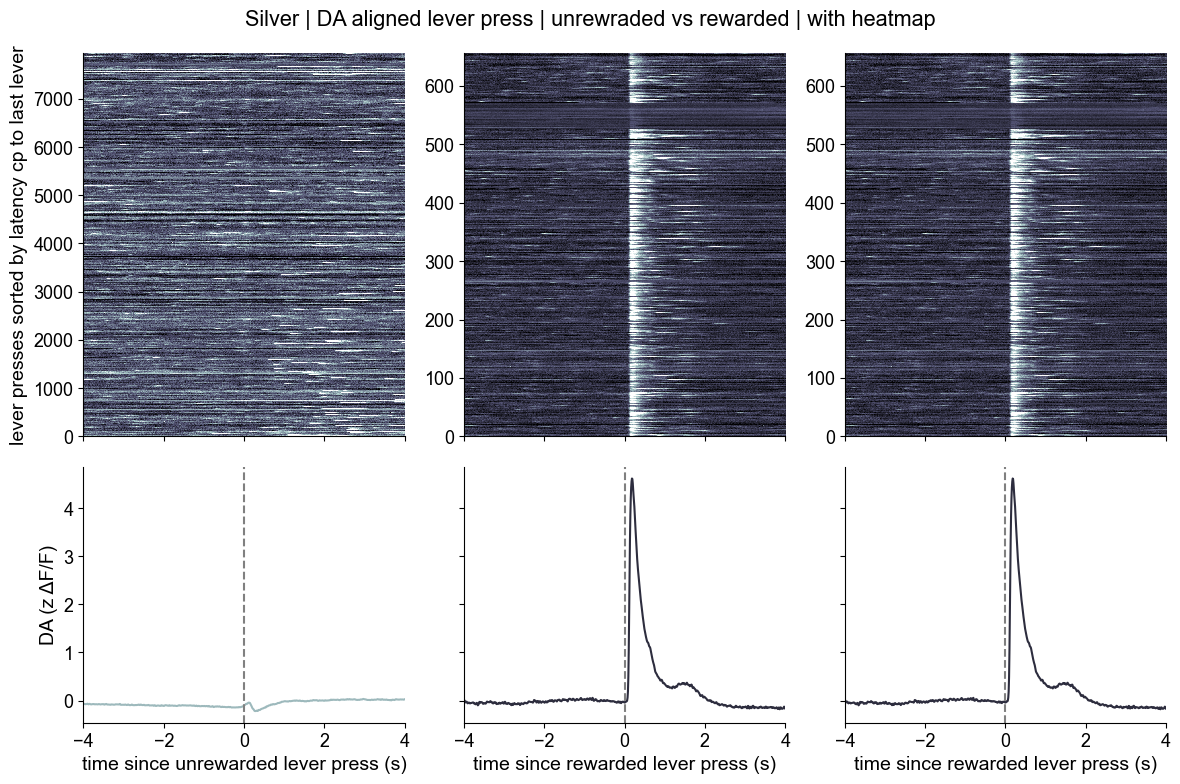

In [ ]:
animal = 'Silver' ## feel free to change the animal + the mask parameters

fig, axs = plt.subplots(2,3, tight_layout = True, figsize = (12,8), sharex = 'col', height_ratios=[3,2])

## share y axes of the bottom row
for col in range(1, 3):
    axs[1, col].sharey(axs[1, 0])
    axs[1, col].tick_params(labelleft=False) # Hide labels


mask = (meta_lever['lever_index']!=-1) & \
       (meta_lever['click'] == False) & \
       (meta_lever['animal'] == animal)

sorted_meta = meta_lever[mask].sort_values(by=['latency_cp_to_last_lever'])
sorted_snippets = snippets_lever[sorted_meta.index, :]

plot_snippets(sorted_snippets, time, axs[0,0], axs[1,0], cmap = 'bone', bool_plot_mean=True, color_DA_traces=non_rwd_color)


mask = (meta_lever['lever_index']==-1) & \
       (meta_lever['click'] == False) & \
       (meta_lever['animal'] == animal)

sorted_meta = meta_lever[mask].sort_values(by=['latency_cp_to_last_lever'])
sorted_snippets = snippets_lever[sorted_meta.index, :]

plot_snippets(sorted_snippets, time, axs[0,1], axs[1,1], cmap = 'bone', bool_plot_mean=True, color_DA_traces=rwd_color)


mask = (meta_last['click'] == False) & \
       (meta_last['animal'] == animal)

sorted_meta = meta_last[mask].sort_values(by=['latency_cp_to_last_lever'])
sorted_snippets = snippets_last[sorted_meta.index, :]

plot_snippets(sorted_snippets, time, axs[0,2], axs[1,2], cmap = 'bone', bool_plot_mean=True, color_DA_traces=rwd_color)

axs[0,0].set_ylabel('lever presses sorted by latency cp to last lever')
axs[1,0].set_ylabel('DA (z ΔF/F)')

[axs[1,ii].axvline(0, ls = '--', color = 'grey') for ii in range(3)]
axs[1,0].set_xlabel('time since unrewarded lever press (s)')
[axs[1,ii].set_xlabel('time since rewarded lever press (s)') for ii in range(1,3)]


figtitle = f'{animal} | DA aligned to lever press | unrewraded vs rewarded | with heatmap'
fig.suptitle(figtitle)
#fig.savefig(fr'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace('|', '_')}.png')

We can also compare across animals

C:\Users\Admin\AppData\Local\Temp\ipykernel_32916\4183592193.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(fr'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace('|', '_')}.png')


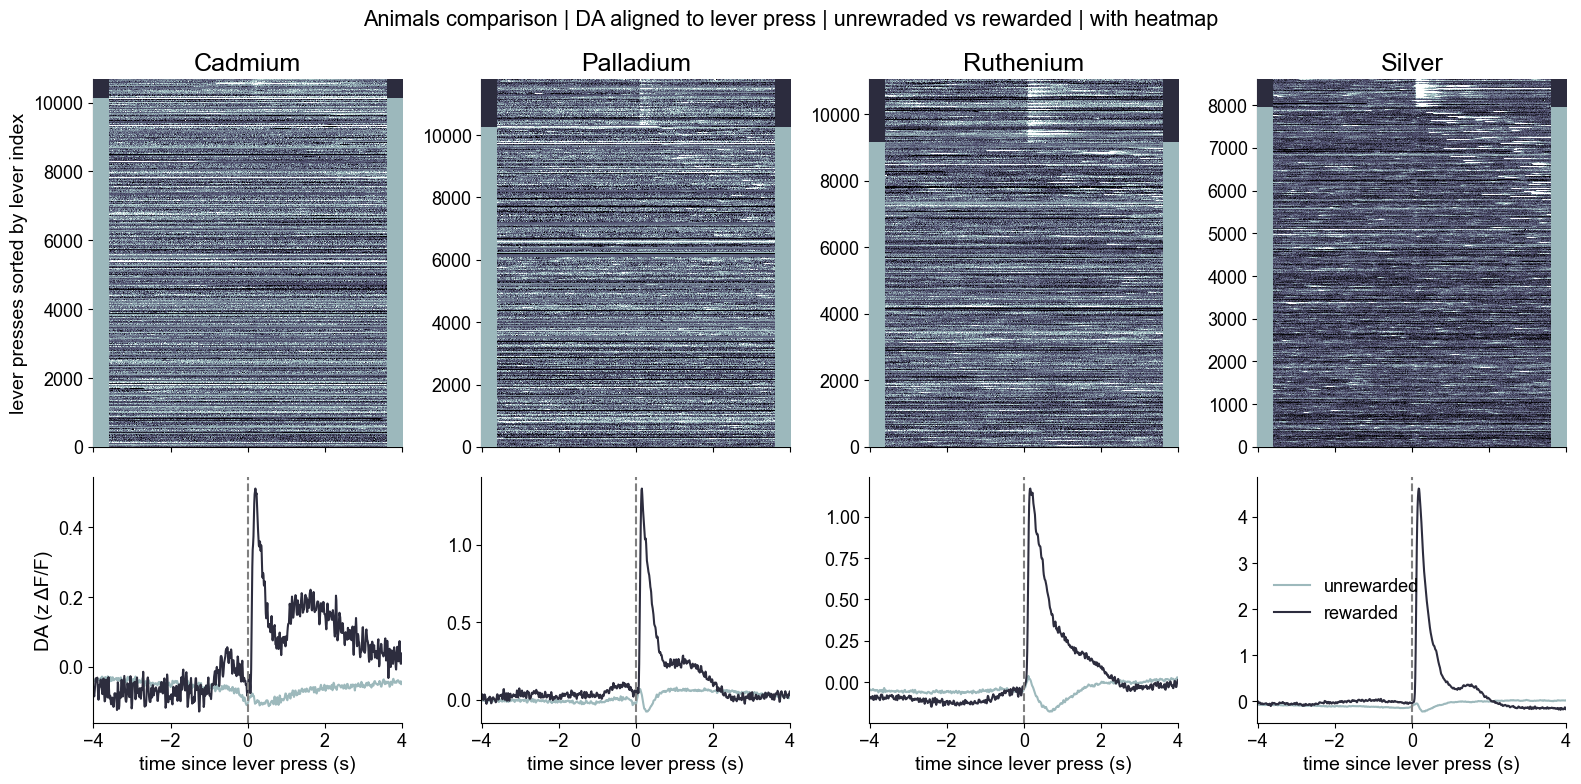

In [93]:
animal_list = meta_lever.animal.unique()
cmap_index = ListedColormap(list([non_rwd_color, rwd_color]))

fig, axs = plt.subplots(2,len(animal_list), tight_layout = True, figsize = (4*len(animal_list),8), sharex = 'col', height_ratios=[3,2])

## share y axes of the bottom row
#for col in range(1, len(animal_list)):
#    axs[1, col].sharey(axs[1, 0])
#    axs[1, col].tick_params(labelleft=False) # Hide labels

for ii,animal in enumerate(animal_list):
    mask = (meta_lever['click'] == False) & \
           (meta_lever['animal'] == animal)

    sorted_meta = meta_lever[mask].sort_values(by=['lever_index'])
    sorted_snippets = snippets_lever[sorted_meta.index, :]

    plot_snippets(sorted_snippets, time, axs[0,ii], axs[1,ii], cmap = 'bone', bool_plot_mean=False)

    axs[1,ii].plot(time, np.nanmean(snippets_lever[mask & (meta_lever['lever_index']!=-1)], axis = 0), color = non_rwd_color, label = 'unrewarded')
    axs[1,ii].plot(time, np.nanmean(snippets_lever[mask & (meta_lever['lever_index']==-1)], axis = 0), color = rwd_color, label = 'rewarded')

    axs[1,ii].axvline(0, ls = '--', color = 'grey')

    index_values = sorted_meta['lever_index'].values == -1

    for loc in ['center left', 'center right']:
        ax_index = inset_axes(axs[0,ii], width="5%", height="100%", loc=loc, borderpad=0)
        ax_index.matshow(index_values.reshape(len(index_values),1), aspect = 'auto', cmap = cmap_index, origin = 'lower')
        ax_index.set_axis_off()

    axs[0,ii].set_title(animal)
    axs[1,ii].set_xlabel('time since lever press (s)')

axs[1,-1].legend(frameon = False)
axs[0,0].set_ylabel('lever presses sorted by lever index')
axs[1,0].set_ylabel('DA (z ΔF/F)')


figtitle = f'Animals comparison | DA aligned to lever press | unrewraded vs rewarded | with heatmap'
fig.suptitle(figtitle)
fig.savefig(fr'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace('|', '_')}.png')


In [103]:
sns.histplot(snippets_last[(meta_last['animal'] == 'Silver'),:])

#plt.plot(np.median(snippets_last[(meta_last['animal'] == 'Silver')], axis = 0))
#plt.plot(np.mean(snippets_last[(meta_last['animal'] == 'Silver')], axis = 0))

<Axes: ylabel='Count'>

c:\Users\Admin\anaconda3\envs\neuro\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


Error in callback <function flush_figures at 0x000002CCE7DAEE80> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

## DAta across experimental conditions

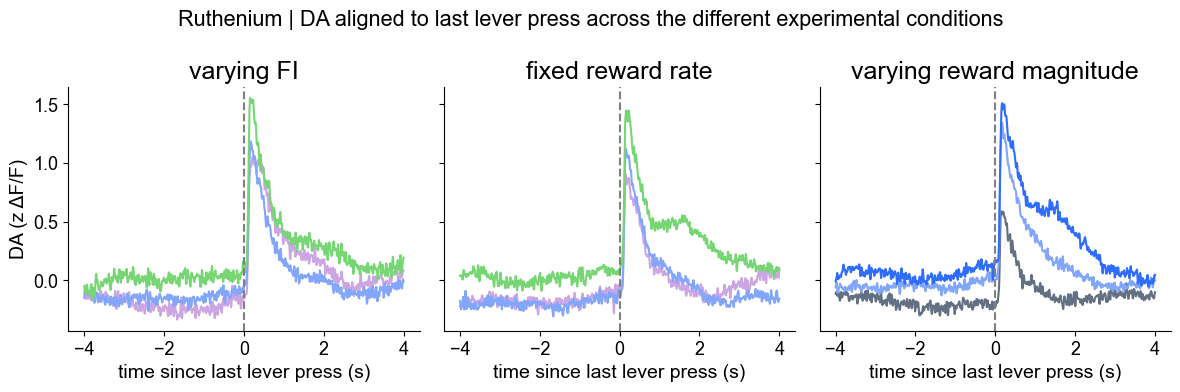

In [23]:
animal = 'Ruthenium'

fig, axs = plt.subplots(1,3, tight_layout = True, figsize = (12,4), sharey = True)

for ii, FI in enumerate(FI_order):
    axs[0].plot(time, np.nanmean(snippets_last[
        meta_last[(meta_last['FI'] == FI) &
                (meta_last['experiment'] == "a") &
                (meta_last['click'] == False) &
                (meta_last['animal'] == animal)].index, :],
        axis = 0),
        color = color_FI_blocks[ii])

for ii, FI in enumerate(FI_order):
    axs[1].plot(time, np.nanmean(snippets_last[
        meta_last[(meta_last['FI'] == FI) &
                (meta_last['experiment'] == "b") &
                (meta_last['click'] == False) &
                (meta_last['animal'] == animal)].index, :],
        axis = 0),
        color = color_FI_blocks[ii])
    
for ii, rwd in enumerate(rwd_order):
    axs[2].plot(time, np.nanmean(snippets_last[
        meta_last[(meta_last['n_protocols'] == rwd) &
                (meta_last['experiment'] == "c") &
                (meta_last['click'] == False) &
                (meta_last['animal'] == animal)].index, :],
        axis = 0),
        color = color_rwd_blocks[ii])


[axs[ii].axvline(0, ls = '--', color = 'grey') for ii in range(3)]
[axs[ii].set_xlabel('time since last lever press (s)') for ii in range(3)]


axs[0].set_title('varying FI')
axs[1].set_title('fixed reward rate')
axs[2].set_title('varying reward magnitude')

axs[0].set_ylabel('DA (z ΔF/F)')

figtitle = f'{animal} | DA aligned to last lever press across the different experimental conditions'
fig.suptitle(figtitle)
fig.savefig(fr'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace('|', '_')}.png')


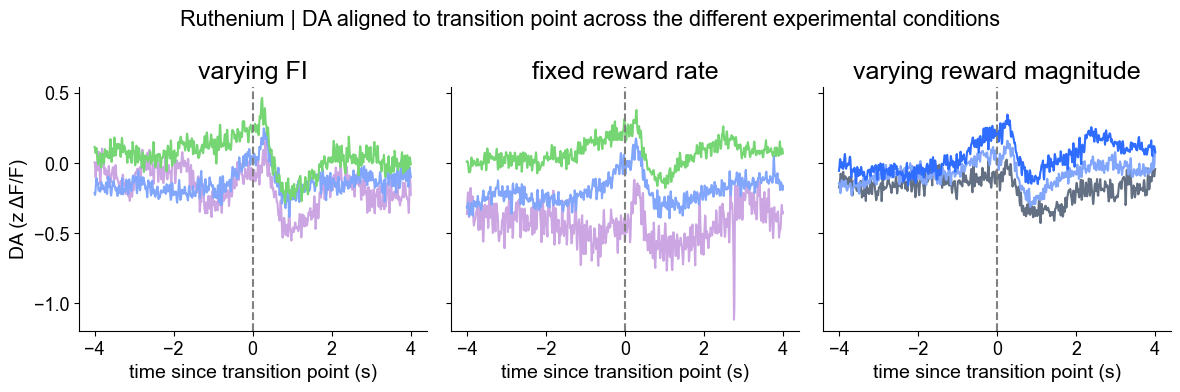

In [24]:
animal = 'Ruthenium'

fig, axs = plt.subplots(1,3, tight_layout = True, figsize = (12,4), sharey = True)

for ii, FI in enumerate(FI_order):
    axs[0].plot(time, np.nanmean(snippets_cp[
        meta_cp[(meta_cp['FI'] == FI) &
                (meta_cp['experiment'] == "a") &
                (meta_cp['click'] == False) &
                (meta_cp['animal'] == animal)].index, :],
        axis = 0),
        color = color_FI_blocks[ii])

for ii, FI in enumerate(FI_order):
    axs[1].plot(time, np.nanmean(snippets_cp[
        meta_cp[(meta_cp['FI'] == FI) &
                (meta_cp['experiment'] == "b") &
                (meta_cp['click'] == False) &
                (meta_cp['animal'] == animal)].index, :],
        axis = 0),
        color = color_FI_blocks[ii])
    
for ii, rwd in enumerate(rwd_order):
    axs[2].plot(time, np.nanmean(snippets_cp[
        meta_cp[(meta_cp['n_protocols'] == rwd) &
                (meta_cp['experiment'] == "c") &
                (meta_cp['click'] == False) &
                (meta_cp['animal'] == animal)].index, :],
        axis = 0),
        color = color_rwd_blocks[ii])


[axs[ii].axvline(0, ls = '--', color = 'grey') for ii in range(3)]
[axs[ii].set_xlabel('time since transition point (s)') for ii in range(3)]


axs[0].set_title('varying FI')
axs[1].set_title('fixed reward rate')
axs[2].set_title('varying reward magnitude')

axs[0].set_ylabel('DA (z ΔF/F)')

figtitle = f'{animal} | DA aligned to transition point across the different experimental conditions'
fig.suptitle(figtitle)
fig.savefig(fr'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace('|', '_')}.png')


C:\Users\Admin\AppData\Local\Temp\ipykernel_32916\3824926706.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(fr'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace('|', '_')}.png')


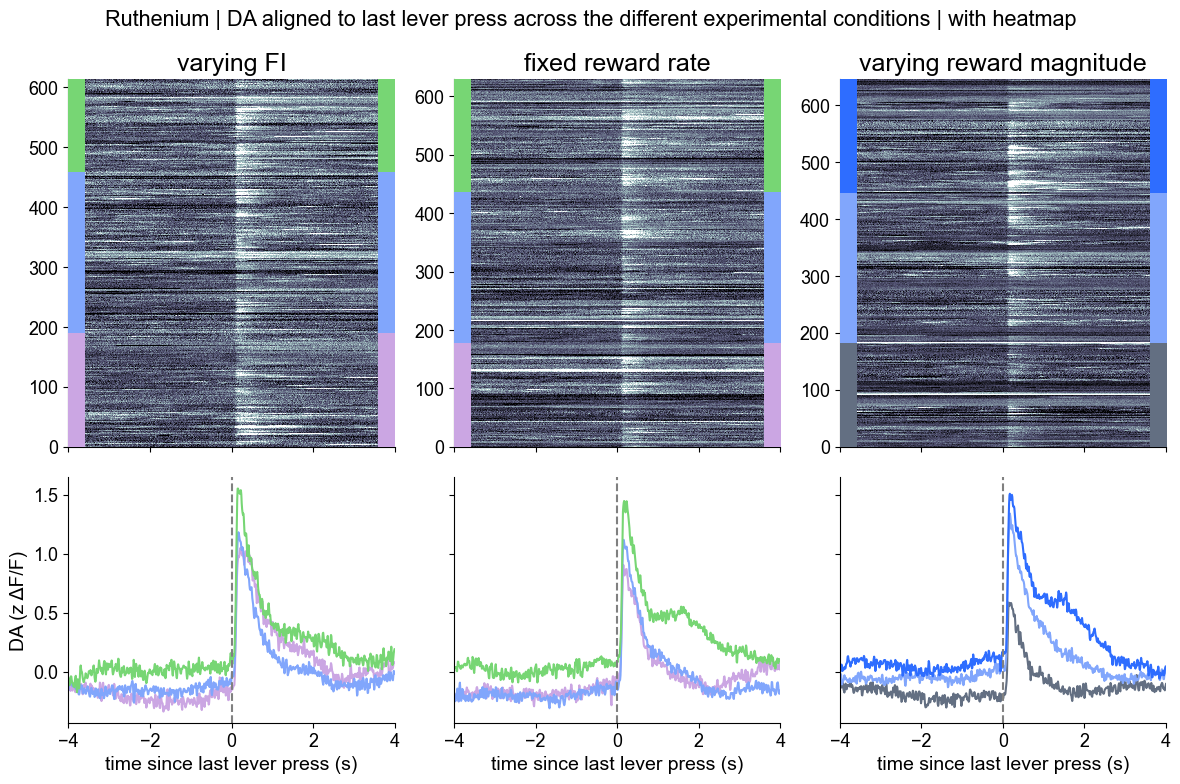

In [41]:
animal = 'Ruthenium'

fig, axs = plt.subplots(2,3, tight_layout = True, figsize = (12,8), sharex = 'col', height_ratios=[3,2])

## share y axes of the bottom row
for col in range(1, 3):
    axs[1, col].sharey(axs[1, 0])
    axs[1, col].tick_params(labelleft=False) # Hide labels


## exp a

mask = (meta_last['experiment'] == "a") & \
       (meta_last['click'] == False) & \
       (meta_last['animal'] == animal)

sorted_meta = meta_last[mask].sort_values(by=['FI'])
sorted_snippets = snippets_last[sorted_meta.index, :]

plot_snippets(sorted_snippets, time, axs[0,0], axs[1,0], cmap = 'bone', bool_plot_mean=False)

for ii, FI in enumerate(FI_order):
    axs[1,0].plot(time, np.nanmean(snippets_last[
        meta_last[(meta_last['FI'] == FI) & mask].index, :],
        axis = 0),
        color = color_FI_blocks[ii])

FI_values = sorted_meta['FI'].values
for loc in ['center left', 'center right']:
    ax_FI = inset_axes(axs[0,0], width="5%", height="100%", loc=loc, borderpad=0)
    ax_FI.matshow(FI_values.reshape(len(FI_values),1), aspect = 'auto', cmap = cmap_FI, origin = 'lower')
    ax_FI.set_axis_off()

## exp b

mask = (meta_last['experiment'] == "b") & \
       (meta_last['click'] == False) & \
       (meta_last['animal'] == animal)

sorted_meta = meta_last[mask].sort_values(by=['FI'])
sorted_snippets = snippets_last[sorted_meta.index, :]

plot_snippets(sorted_snippets, time, axs[0,1], axs[1,1], cmap = 'bone', bool_plot_mean=False)

for ii, FI in enumerate(FI_order):
    axs[1,1].plot(time, np.nanmean(snippets_last[
        meta_last[(meta_last['FI'] == FI) & mask].index, :],
        axis = 0),
        color = color_FI_blocks[ii])

FI_values = sorted_meta['FI'].values
for loc in ['center left', 'center right']:
    ax_FI = inset_axes(axs[0,1], width="5%", height="100%", loc=loc, borderpad=0)
    ax_FI.matshow(FI_values.reshape(len(FI_values),1), aspect = 'auto', cmap = cmap_FI, origin = 'lower')
    ax_FI.set_axis_off()


## exp c 
mask = (meta_last['experiment'] == "c") & \
       (meta_last['click'] == False) & \
       (meta_last['animal'] == animal)

sorted_meta = meta_last[mask].sort_values(by=['n_protocols'])
sorted_snippets = snippets_last[sorted_meta.index, :]

plot_snippets(sorted_snippets, time, axs[0,2], axs[1,2], cmap = 'bone', bool_plot_mean=False)

for ii, rwd in enumerate(rwd_order):
    axs[1,2].plot(time, np.nanmean(snippets_last[
        meta_last[(meta_last['n_protocols'] == rwd) & mask].index, :],
        axis = 0),
        color = color_rwd_blocks[ii])

rwd_values = sorted_meta['n_protocols'].values
for loc in ['center left', 'center right']:
    ax_rwd = inset_axes(axs[0,2], width="5%", height="100%", loc=loc, borderpad=0)
    ax_rwd.matshow(rwd_values.reshape(len(rwd_values),1), aspect = 'auto', cmap = cmap_rwd, origin = 'lower')
    ax_rwd.set_axis_off()


[axs[1,ii].axvline(0, ls = '--', color = 'grey') for ii in range(3)]
[axs[1,ii].set_xlabel('time since last lever press (s)') for ii in range(3)]


axs[0,0].set_title('varying FI')
axs[0,1].set_title('fixed reward rate')
axs[0,2].set_title('varying reward magnitude')

axs[1,0].set_ylabel('DA (z ΔF/F)')

figtitle = f'{animal} | DA aligned to last lever press across the different experimental conditions | with heatmap'
fig.suptitle(figtitle)
fig.savefig(fr'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace('|', '_')}.png')


C:\Users\Admin\AppData\Local\Temp\ipykernel_32916\624073805.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(fr'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace('|', '_')}.png')


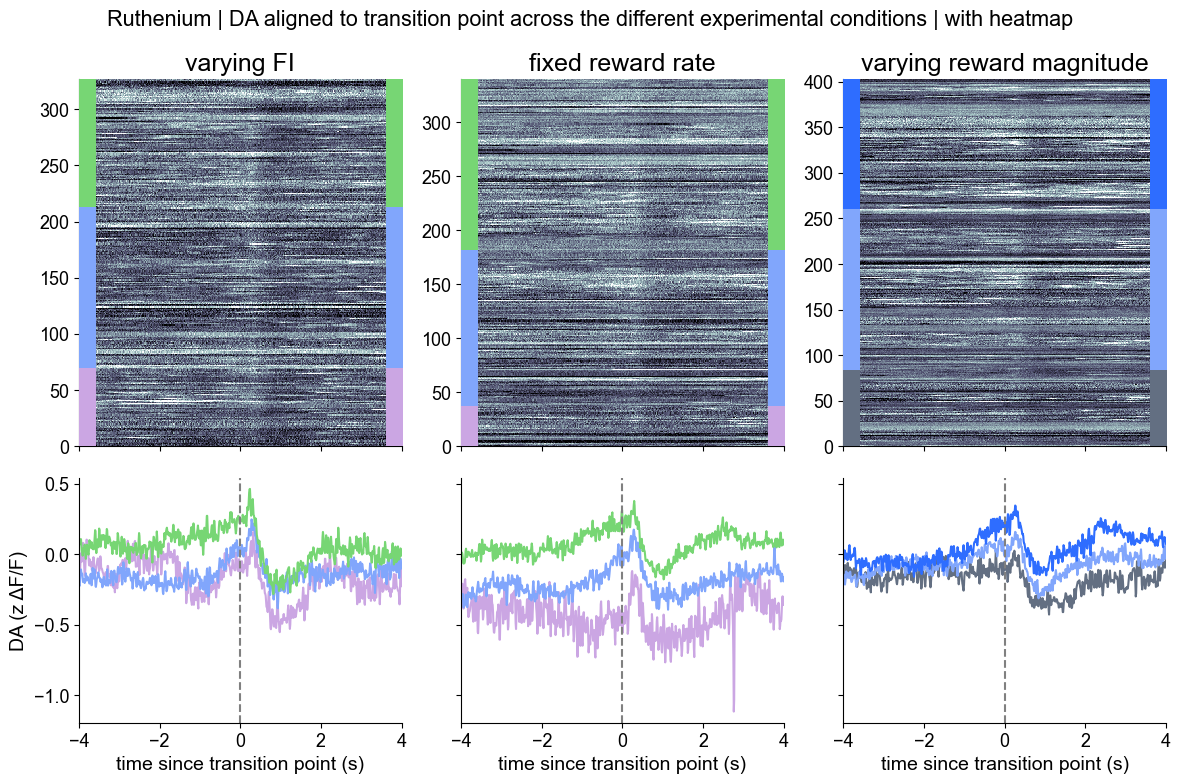

In [44]:
animal = 'Ruthenium'

fig, axs = plt.subplots(2,3, tight_layout = True, figsize = (12,8), sharex = 'col', height_ratios=[3,2])

## share y axes of the bottom row
for col in range(1, 3):
    axs[1, col].sharey(axs[1, 0])
    axs[1, col].tick_params(labelleft=False) # Hide labels


## exp a

mask = (meta_cp['bool_cp'] == True) & \
       (meta_cp['experiment'] == "a") & \
       (meta_cp['click'] == False) & \
       (meta_cp['animal'] == animal)

sorted_meta = meta_cp[mask].sort_values(by=['FI'])
sorted_snippets = snippets_cp[sorted_meta.index, :]

plot_snippets(sorted_snippets, time, axs[0,0], axs[1,0], cmap = 'bone', bool_plot_mean=False)

for ii, FI in enumerate(FI_order):
    axs[1,0].plot(time, np.nanmean(snippets_cp[
        meta_cp[(meta_cp['FI'] == FI) & mask].index, :],
        axis = 0),
        color = color_FI_blocks[ii])

FI_values = sorted_meta['FI'].values
for loc in ['center left', 'center right']:
    ax_FI = inset_axes(axs[0,0], width="5%", height="100%", loc=loc, borderpad=0)
    ax_FI.matshow(FI_values.reshape(len(FI_values),1), aspect = 'auto', cmap = cmap_FI, origin = 'lower')
    ax_FI.set_axis_off()

## exp b

mask = (meta_cp['bool_cp'] == True) & \
       (meta_cp['experiment'] == "b") & \
       (meta_cp['click'] == False) & \
       (meta_cp['animal'] == animal)

sorted_meta = meta_cp[mask].sort_values(by=['FI'])
sorted_snippets = snippets_cp[sorted_meta.index, :]

plot_snippets(sorted_snippets, time, axs[0,1], axs[1,1], cmap = 'bone', bool_plot_mean=False)

for ii, FI in enumerate(FI_order):
    axs[1,1].plot(time, np.nanmean(snippets_cp[
        meta_cp[(meta_cp['FI'] == FI) & mask].index, :],
        axis = 0),
        color = color_FI_blocks[ii])

FI_values = sorted_meta['FI'].values
for loc in ['center left', 'center right']:
    ax_FI = inset_axes(axs[0,1], width="5%", height="100%", loc=loc, borderpad=0)
    ax_FI.matshow(FI_values.reshape(len(FI_values),1), aspect = 'auto', cmap = cmap_FI, origin = 'lower')
    ax_FI.set_axis_off()


## exp c 
mask = (meta_cp['bool_cp'] == True) & \
       (meta_cp['experiment'] == "c") & \
       (meta_cp['click'] == False) & \
       (meta_cp['animal'] == animal)

sorted_meta = meta_cp[mask].sort_values(by=['n_protocols'])
sorted_snippets = snippets_cp[sorted_meta.index, :]

plot_snippets(sorted_snippets, time, axs[0,2], axs[1,2], cmap = 'bone', bool_plot_mean=False)

for ii, rwd in enumerate(rwd_order):
    axs[1,2].plot(time, np.nanmean(snippets_cp[
        meta_cp[(meta_cp['n_protocols'] == rwd) & mask].index, :],
        axis = 0),
        color = color_rwd_blocks[ii])

rwd_values = sorted_meta['n_protocols'].values
for loc in ['center left', 'center right']:
    ax_rwd = inset_axes(axs[0,2], width="5%", height="100%", loc=loc, borderpad=0)
    ax_rwd.matshow(rwd_values.reshape(len(rwd_values),1), aspect = 'auto', cmap = cmap_rwd, origin = 'lower')
    ax_rwd.set_axis_off()


[axs[1,ii].axvline(0, ls = '--', color = 'grey') for ii in range(3)]
[axs[1,ii].set_xlabel('time since transition point (s)') for ii in range(3)]


axs[0,0].set_title('varying FI')
axs[0,1].set_title('fixed reward rate')
axs[0,2].set_title('varying reward magnitude')

axs[1,0].set_ylabel('DA (z ΔF/F)')

figtitle = f'{animal} | DA aligned to transition point across the different experimental conditions | with heatmap'
fig.suptitle(figtitle)
fig.savefig(fr'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace('|', '_')}.png')


In [65]:
alignment_idx = 1
DA_column = 'DA_zscored_session'
window = (-4,4)

time, snippets_T1 = compute_snippets_across_days(aggregated_jointdf.query(f'animal == "{animal}"'),
        f'tercile_cp_withinFI == "T1" and FI == 30', alignments[alignment_idx], DA_column, window)

_, snippets_T2 = compute_snippets_across_days(aggregated_jointdf.query(f'animal == "{animal}"'),
        f'tercile_cp_withinFI == "T2" and FI == 30', alignments[alignment_idx], DA_column, window)

_, snippets_T3 = compute_snippets_across_days(aggregated_jointdf.query(f'animal == "{animal}"'),
        f'tercile_cp_withinFI == "T3" and FI == 30', alignments[alignment_idx], DA_column, window)

#snippets_T1 = drop_nan_rows_in_matrix(snippets)
    #rwd_vals = nprots*np.ones(len(snippets))
    #snippets_c.append(snippets)
    #rwd_c.append(rwd_vals)

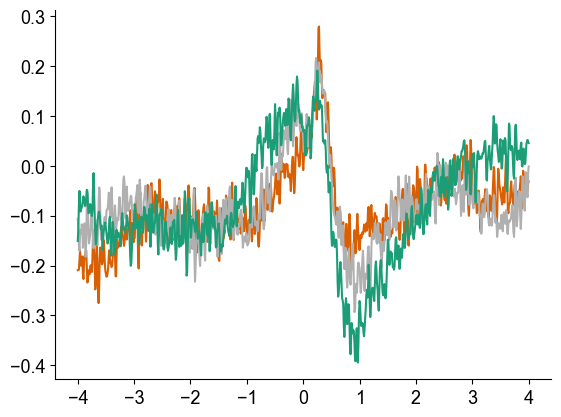

In [64]:
plt.plot(time, np.nanmean(snippets_T1, axis = 0), color = tercile_colors[0])
plt.plot(time, np.nanmean(snippets_T2, axis = 0), color = tercile_colors[1])
plt.plot(time, np.nanmean(snippets_T3, axis = 0), color = tercile_colors[2])

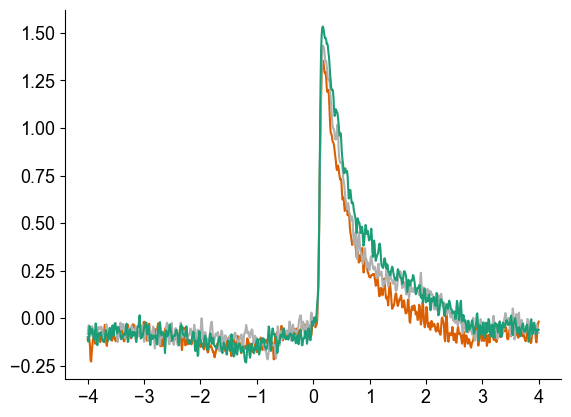

In [66]:
plt.plot(time, np.nanmean(snippets_T1, axis = 0), color = tercile_colors[0])
plt.plot(time, np.nanmean(snippets_T2, axis = 0), color = tercile_colors[1])
plt.plot(time, np.nanmean(snippets_T3, axis = 0), color = tercile_colors[2])

## exploded subtitle

In [67]:
def align_DA_to_ttls(blocksdf, ttl_column, DA_column = 'DA_zscored_per_session', alignment_window=(-2, 2), bin_size=0.01):
    """
    Align DA activity to TTL events for each session in blocksdf.

    Parameters:
    -----------
    blocksdf : pd.DataFrame
        DataFrame containing DA activity and TTL events. Must include 'animaldate', 'time_DA', and 'DA'.
    ttl_column : str
        Column name in blocksdf containing TTL events to align DA activity to.
    alignment_window : tuple, optional
        Time window around TTL events to align DA activity (default: (-2, 2)).
    bin_size : float, optional
        Size of bins for alignment (default: 0.01 seconds).

    Returns:
    --------
    aligned_snippets : dict
        Dictionary where keys are 'animaldate' and values are aligned DA snippets for each session.
    alignment_time : np.array
        Array of time bins used for alignment.
    """
    aligned_snippets = {}
    all_snippets = []  # List to collect all snippets

    n_timestamps = 1 + (alignment_window[1]-alignment_window[0])/bin_size

    for animaldate in blocksdf['animaldate'].unique():
        session_df = blocksdf.query(f'animaldate == "{animaldate}"')
        time_DA = np.hstack(session_df['time_DA'].values)
        DA_signal = np.hstack(session_df[DA_column].values)
        ttl_events = session_df[ttl_column].values  # Use the specified TTL column

        # Align DA activity to TTL events
        snippets, time = signal2eventsnippets(time_DA, DA_signal, ttl_events, alignment_window, bin_size, nanify=False)
        aligned_snippets[animaldate] = snippets
        all_snippets.append(snippets)

    all_snippets = np.vstack(all_snippets)

    return aligned_snippets, time, all_snippets

In [68]:
aggregated_jointdf.animaldate[aggregated_jointdf.apply(lambda x: type(x.lever_index), axis = 1) == float].unique()


array([], dtype=object)

In [69]:
#exploded_df = aggregated_jointdf.query(f'date in {list(dates)}').explode(['lever_abs','lever_index', 'lever_index_category'])
exploded_df = aggregated_jointdf.explode(['lever_abs','lever_index', 'lever_index_category'])
exploded_df = exploded_df[exploded_df['lever_index'].notna()]  # Remove NaNs
exploded_df['lever_index'] = pd.to_numeric(exploded_df['lever_index'], errors='coerce')  # Ensure numeric

_, time, all_snippets = align_DA_to_ttls(exploded_df, 'lever_abs', 'DA_zscored_session', alignment_window=(-2, 2), bin_size=0.01)
# Discard rows with NaNs
cleaned_snippets = all_snippets[~np.isnan(all_snippets).any(axis=1)]

Text(0.5, 0.98, 'DA aligned to rewarded and unrewarded lever presses')

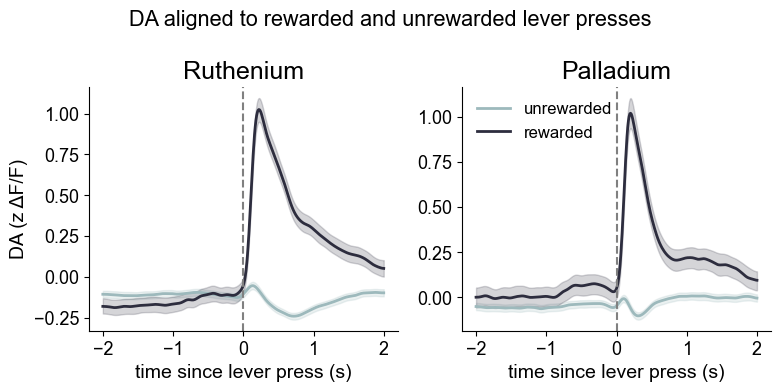

In [70]:

fig, axs = plt.subplots(1,2, tight_layout = True, figsize = (8,4))

rwd_color = bone_cmap(.2)
non_rwd_color = bone_cmap(.7)

t_4 = np.linspace(-2,2,401)

animal = 'Ruthenium'
non_rwd_mask = (exploded_df['lever_index'] < -1) & (exploded_df['animal'] == animal)
rwd_mask = (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)

median, lower, upper = bootstrap_ci(all_snippets[non_rwd_mask], n_boot=500, smooth_sigma=5)
axs[0].plot(t_4, median, color = non_rwd_color, lw = 2, label = 'unrewarded press')
axs[0].fill_between(t_4, lower, upper, color=non_rwd_color, alpha=0.2)

median, lower, upper = bootstrap_ci(all_snippets[rwd_mask], n_boot=500, smooth_sigma=5)
axs[0].plot(t_4, median, color = rwd_color, lw = 2, label = 'rewarded press')
axs[0].fill_between(t_4, lower, upper, color=rwd_color, alpha=0.2)

#axs[0].plot(np.nanmean(all_snippets[non_rwd_mask], axis = 0), color = bone_cmap(0.7), lw = 2)
#axs[0].plot(np.nanmean(all_snippets[rwd_mask], axis = 0), color = bone_cmap(0.2), lw = 2)

animal = 'Palladium'
non_rwd_mask = (exploded_df['lever_index'] < -1) & (exploded_df['animal'] == animal)
rwd_mask = (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
#axs[1].plot(np.nanmean(all_snippets[non_rwd_mask], axis = 0), color = bone_cmap(0.7), lw = 2)
#axs[1].plot(np.nanmean(all_snippets[rwd_mask], axis = 0), color = bone_cmap(0.2), lw = 2)

median, lower, upper = bootstrap_ci(all_snippets[non_rwd_mask], n_boot=500, smooth_sigma=5)
axs[1].plot(t_4, median, color = non_rwd_color, lw = 2, label = 'unrewarded')
axs[1].fill_between(t_4, lower, upper, color=non_rwd_color, alpha=0.2)

median, lower, upper = bootstrap_ci(all_snippets[rwd_mask], n_boot=500, smooth_sigma=5)
axs[1].plot(t_4, median, color = rwd_color, lw = 2, label = 'rewarded')
axs[1].fill_between(t_4, lower, upper, color=rwd_color, alpha=0.2)

[axs[ii].axvline(0, color = 'grey', ls = '--') for ii in range(2)]
[axs[ii].set_xlabel('time since lever press (s)') for ii in range(2)]

axs[0].set_ylabel('DA (z ΔF/F)')

axs[1].legend(frameon = False, fontsize = 12)

axs[0].set_title('Ruthenium')
axs[1].set_title('Palladium')

figtitle = 'DA aligned to rewarded and unrewarded lever presses'
plt.suptitle(figtitle)

#plt.savefig(rf'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace('|','_')}.png')

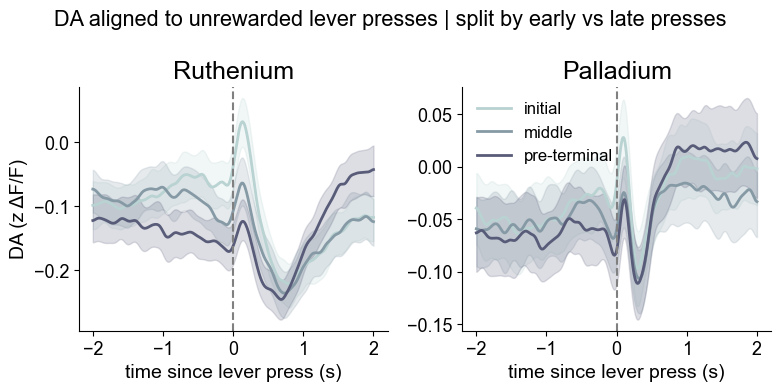

In [71]:

fig, axs = plt.subplots(1,2, tight_layout = True, figsize = (8,4))

labels = ['initial', 'middle', 'pre-terminal']

animal = 'Ruthenium'
mask_presses_t1 = (exploded_df['bool_cp'] == True) & (exploded_df['lever_index_category'] == 't1') & (exploded_df['animal'] == animal)
mask_presses_t2 = (exploded_df['bool_cp'] == True) & (exploded_df['lever_index_category'] == 't2') & (exploded_df['animal'] == animal)
mask_presses_t3 = (exploded_df['bool_cp'] == True) & (exploded_df['lever_index_category'] == 't3') & (exploded_df['animal'] == animal)
mask_presses_last = (exploded_df['bool_cp'] == True) & (exploded_df['lever_index_category'] == 'last') & (exploded_df['animal'] == animal)
masks = [mask_presses_t1, mask_presses_t2, mask_presses_t3]

for ii, mask in enumerate(masks):

    color = bone_cmap(.8-.2*ii) ## start with 0.2 if including the last lever press
    
    median, lower, upper = bootstrap_ci(all_snippets[mask], n_boot=50, smooth_sigma=5)
    axs[0].plot(t_4, median, color = color, lw = 2, label = labels[ii])
    axs[0].fill_between(t_4, lower, upper, color=color, alpha=0.2)


animal = 'Palladium'
mask_presses_t1 = (exploded_df['bool_cp'] == True) & (exploded_df['lever_index_category'] == 't1') & (exploded_df['animal'] == animal)
mask_presses_t2 = (exploded_df['bool_cp'] == True) & (exploded_df['lever_index_category'] == 't2') & (exploded_df['animal'] == animal)
mask_presses_t3 = (exploded_df['bool_cp'] == True) & (exploded_df['lever_index_category'] == 't3') & (exploded_df['animal'] == animal)
mask_presses_last = (exploded_df['bool_cp'] == True) & (exploded_df['lever_index_category'] == 'last') & (exploded_df['animal'] == animal)
masks = [mask_presses_t1, mask_presses_t2, mask_presses_t3]

for ii, mask in enumerate(masks):

    color = bone_cmap(.8-.2*ii)
    
    median, lower, upper = bootstrap_ci(all_snippets[mask], n_boot=50, smooth_sigma=5)
    axs[1].plot(t_4, median, color = color, lw = 2, label = labels[ii])
    axs[1].fill_between(t_4, lower, upper, color=color, alpha=0.2)

[axs[ii].axvline(0, color = 'grey', ls = '--') for ii in range(2)]
[axs[ii].set_xlabel('time since lever press (s)') for ii in range(2)]

axs[0].set_ylabel('DA (z ΔF/F)')

axs[1].legend(frameon = False, fontsize = 12)

axs[0].set_title('Ruthenium')
axs[1].set_title('Palladium')

figtitle = 'DA aligned to unrewarded lever presses | split by early vs late presses'
#figtitle = 'DA aligned to rewarded and unrewarded lever presses | split by early vs late presses'
plt.suptitle(figtitle)

plt.savefig(rf'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace('|','_')}.png')

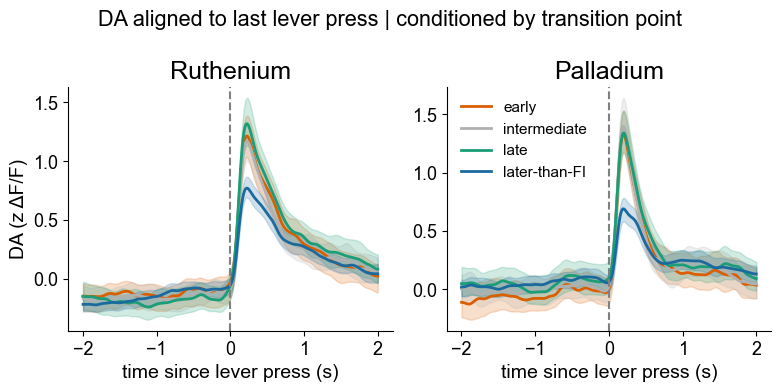

In [ ]:
#aggregated_jointdf['rateH'] = aggregated_jointdf.query('bool_cp').apply(lambda x: len(x.lever_rel[x.lever_rel >= x.cp])/(x.trial_duration - x.cp), axis = 1)
#
#aggregated_jointdf['tercile_rateH'] = (
#    aggregated_jointdf['rateH']
#    #.groupby(['FI'])['cp']
#    .transform(terciles)
#)
#%%
fig, axs = plt.subplots(1,2, tight_layout = True, figsize = (8,4))

color_non_transition = '#1b6a9e'
labels = ['early', 'intermediate', 'late', 'later-than-FI']

animal = 'Ruthenium'

mask_cp_T1 = (exploded_df['tercile_cp_FInormalised'] == 'T1') & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
mask_cp_T2 = (exploded_df['tercile_cp_FInormalised'] == 'T2') & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
mask_cp_T3 = (exploded_df['tercile_cp_FInormalised'] == 'T3') & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
#mask_cp_trial = (exploded_df['bool_cp'] == True) & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
mask_nocp_trial = (exploded_df['bool_cp'] == False) & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
masks = [mask_cp_T1,mask_cp_T2, mask_cp_T3, mask_nocp_trial]

for ii, mask in enumerate(masks):

    color = tercile_colors[ii] if ii < 3 else color_non_transition
    
    median, lower, upper = bootstrap_ci(all_snippets[mask], n_boot=50, smooth_sigma=5)
    axs[0].plot(t_4, median, color = color, lw = 2, label = labels[ii])
    axs[0].fill_between(t_4, lower, upper, color=color, alpha=0.2)


animal = 'Palladium'

mask_cp_T1 = (exploded_df['tercile_cp_FInormalised'] == 'T1') & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
mask_cp_T2 = (exploded_df['tercile_cp_FInormalised'] == 'T2') & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
mask_cp_T3 = (exploded_df['tercile_cp_FInormalised'] == 'T3') & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
#mask_cp_trial = (exploded_df['bool_cp'] == True) & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
mask_nocp_trial = (exploded_df['bool_cp'] == False) & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
masks = [mask_cp_T1,mask_cp_T2, mask_cp_T3, mask_nocp_trial]

for ii, mask in enumerate(masks):

    color = tercile_colors[ii] if ii < 3 else color_non_transition
    
    median, lower, upper = bootstrap_ci(all_snippets[mask], n_boot=50, smooth_sigma=5)
    axs[1].plot(t_4, median, color = color, lw = 2, label = labels[ii])
    axs[1].fill_between(t_4, lower, upper, color=color, alpha=0.2)


[axs[ii].axvline(0, color = 'grey', ls = '--') for ii in range(2)]
[axs[ii].set_xlabel('time since lever press (s)') for ii in range(2)]

axs[0].set_ylabel('DA (z ΔF/F)')

axs[1].legend(frameon = False, fontsize = 11)

axs[0].set_title('Ruthenium')
axs[1].set_title('Palladium')

figtitle = 'DA aligned to last lever press | conditioned by transition point'
plt.suptitle(figtitle)

#plt.savefig(rf'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace('|','_')}.png')

Text(0.5, 0.98, 'DA aligned to transition point | conditioned by transition point')

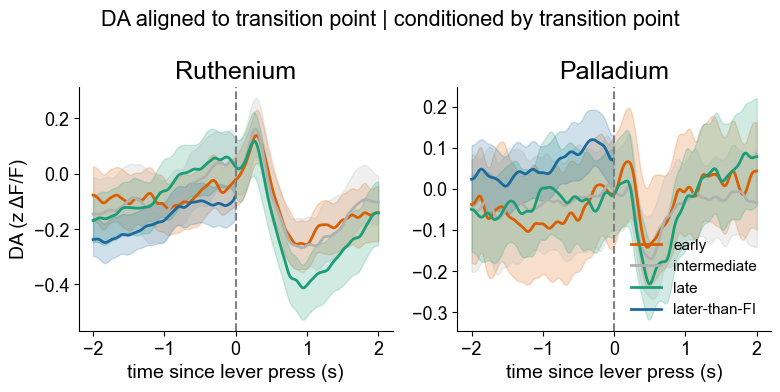

In [73]:
fig, axs = plt.subplots(1,2, tight_layout = True, figsize = (8,4))

labels = ['early', 'intermediate', 'late', 'later-than-FI']

animal = 'Ruthenium'
df = aggregated_jointdf.query(f'animal == "{animal}"')# and date in {photometry_dates_dict[animal]}')
_, snippets_cp_T1 = compute_snippets_across_days(df,f'bool_cp and tercile_cp_FInormalised == "T1"', 'cp_abs','DA_zscored_session', (-2,2))
_, snippets_cp_T2 = compute_snippets_across_days(df,f'bool_cp and tercile_cp_FInormalised == "T2"', 'cp_abs','DA_zscored_session', (-2,2))
_, snippets_cp_T3 = compute_snippets_across_days(df,f'bool_cp and tercile_cp_FInormalised == "T3"', 'cp_abs','DA_zscored_session', (-2,2))
_, snippets_cp_afterFI = compute_snippets_across_days(df,f'bool_cp == False and count_lever < 3', 'last_lever_abs','DA_zscored_session', (-2,2))

all_cp_snippets = [snippets_cp_T1, snippets_cp_T2, snippets_cp_T3]

for ii, snippets in enumerate(all_cp_snippets):
    color = tercile_colors[ii] if ii < 3 else color_non_transition

    median, lower, upper = bootstrap_ci(snippets, n_boot=50, smooth_sigma=5)
    axs[0].plot(t_4, median, color = color, lw = 2, label = labels[ii])
    axs[0].fill_between(t_4, lower, upper, color=color, alpha=0.2)

## pre lever later-than-FI presses
mask_nocp_trial = (exploded_df['count_lever'] < 3) & (exploded_df['bool_cp'] == False) & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
median, lower, upper = bootstrap_ci(all_snippets[mask_nocp_trial], n_boot=50, smooth_sigma=5)
axs[0].plot(t_4[:200], median[:200], color = color_non_transition, lw = 2, label = labels[ii])
axs[0].fill_between(t_4[:200], lower[:200], upper[:200], color=color_non_transition, alpha=0.2)


animal = 'Palladium'
df = aggregated_jointdf.query(f'animal == "{animal}"')# and date in {photometry_dates_dict[animal]}')
_, snippets_cp_T1 = compute_snippets_across_days(df,f'bool_cp and tercile_cp_FInormalised == "T1"', 'cp_abs','DA_zscored_session', (-2,2))
_, snippets_cp_T2 = compute_snippets_across_days(df,f'bool_cp and tercile_cp_FInormalised == "T2"', 'cp_abs','DA_zscored_session', (-2,2))
_, snippets_cp_T3 = compute_snippets_across_days(df,f'bool_cp and tercile_cp_FInormalised == "T3"', 'cp_abs','DA_zscored_session', (-2,2))
_, snippets_cp_afterFI = compute_snippets_across_days(df,f'bool_cp == False and count_lever == 1', 'last_lever_abs','DA_zscored_session', (-2,2))

all_cp_snippets = [snippets_cp_T1, snippets_cp_T2, snippets_cp_T3]

for ii, snippets in enumerate(all_cp_snippets):
    color = tercile_colors[ii] if ii < 3 else color_non_transition

    median, lower, upper = bootstrap_ci(snippets, n_boot=50, smooth_sigma=5)
    axs[1].plot(t_4, median, color = color, lw = 2, label = labels[ii])
    axs[1].fill_between(t_4, lower, upper, color=color, alpha=0.2)

## pre lever later-than-FI presses
mask_nocp_trial = (exploded_df['count_lever'] < 3) & (exploded_df['bool_cp'] == False) & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
median, lower, upper = bootstrap_ci(all_snippets[mask_nocp_trial], n_boot=50, smooth_sigma=5)
axs[1].plot(t_4[:200], median[:200], color = color_non_transition, lw = 2, label = labels[-1])
axs[1].fill_between(t_4[:200], lower[:200], upper[:200], color=color_non_transition, alpha=0.2)


[axs[ii].axvline(0, color = 'grey', ls = '--') for ii in range(2)]
[axs[ii].set_xlabel('time since lever press (s)') for ii in range(2)]

axs[0].set_ylabel('DA (z ΔF/F)')

axs[1].legend(frameon = False, fontsize = 11)

axs[0].set_title('Ruthenium')
axs[1].set_title('Palladium')

figtitle = 'DA aligned to transition point | conditioned by transition point'
plt.suptitle(figtitle)

#plt.savefig(rf'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace('|','_')}.png')

Text(0.5, 0.98, 'DA aligned to last press | conditioned by transition point | exp a same rwd magnitude')

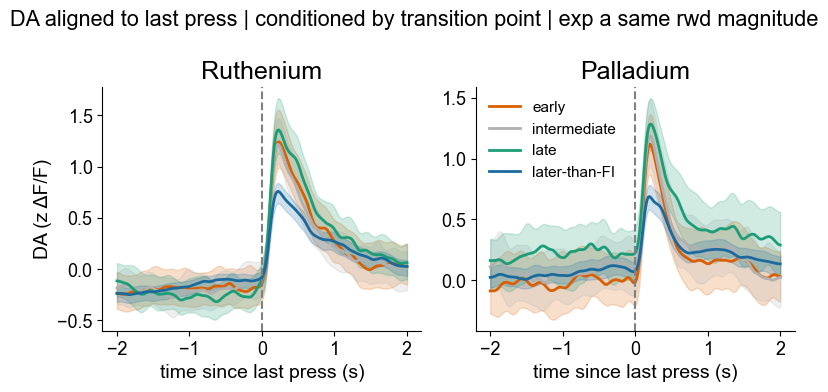

In [74]:
fig, axs = plt.subplots(1,2, tight_layout = True, figsize = (8,4))

labels = ['early', 'intermediate', 'late', 'later-than-FI']

animal1 = 'Ruthenium'
animal2 = 'Palladium'

animal = animal1
df = aggregated_jointdf.query(f'animal == "{animal}"')# and date in {photometry_dates_dict[animal]}')
_, snippets_cp_T1 = compute_snippets_across_days(df,f'bool_cp and experiment == "a" and tercile_cp_FInormalised == "T1"', 'last_lever_abs','DA_zscored_session', (-2,2))
_, snippets_cp_T2 = compute_snippets_across_days(df,f'bool_cp and experiment == "a" and tercile_cp_FInormalised == "T2"', 'last_lever_abs','DA_zscored_session', (-2,2))
_, snippets_cp_T3 = compute_snippets_across_days(df,f'bool_cp and experiment == "a" and tercile_cp_FInormalised == "T3"', 'last_lever_abs','DA_zscored_session', (-2,2))
_, snippets_cp_afterFI = compute_snippets_across_days(df,f'bool_cp == False and experiment == "a" and count_lever < 3', 'last_lever_abs','DA_zscored_session', (-2,2))

all_cp_snippets = [snippets_cp_T1, snippets_cp_T2, snippets_cp_T3]

for ii, snippets in enumerate(all_cp_snippets):
    color = tercile_colors[ii] if ii < 3 else color_non_transition

    median, lower, upper = bootstrap_ci(snippets, n_boot=50, smooth_sigma=5)
    axs[0].plot(t_4, median, color = color, lw = 2, label = labels[ii])
    axs[0].fill_between(t_4, lower, upper, color=color, alpha=0.2)

## pre lever later-than-FI presses
mask_nocp_trial = (exploded_df['count_lever'] < 3) & (exploded_df['bool_cp'] == False) & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
median, lower, upper = bootstrap_ci(all_snippets[mask_nocp_trial], n_boot=50, smooth_sigma=5)
axs[0].plot(t_4, median, color = color_non_transition, lw = 2, label = labels[ii])
axs[0].fill_between(t_4, lower, upper, color=color_non_transition, alpha=0.2)


animal = animal2
df = aggregated_jointdf.query(f'animal == "{animal}"')# and date in {photometry_dates_dict[animal]}')
_, snippets_cp_T1 = compute_snippets_across_days(df,f'bool_cp and experiment == "a" and tercile_cp_FInormalised == "T1"', 'last_lever_abs','DA_zscored_session', (-2,2))
_, snippets_cp_T2 = compute_snippets_across_days(df,f'bool_cp and experiment == "a" and tercile_cp_FInormalised == "T2"', 'last_lever_abs','DA_zscored_session', (-2,2))
_, snippets_cp_T3 = compute_snippets_across_days(df,f'bool_cp and experiment == "a" and tercile_cp_FInormalised == "T3"', 'last_lever_abs','DA_zscored_session', (-2,2))
_, snippets_cp_afterFI = compute_snippets_across_days(df,f'bool_cp == False and experiment == "a" and count_lever == 1', 'last_lever_abs','DA_zscored_session', (-2,2))

all_cp_snippets = [snippets_cp_T1, snippets_cp_T2, snippets_cp_T3]

for ii, snippets in enumerate(all_cp_snippets):
    color = tercile_colors[ii] if ii < 3 else color_non_transition

    median, lower, upper = bootstrap_ci(snippets, n_boot=50, smooth_sigma=5)
    axs[1].plot(t_4, median, color = color, lw = 2, label = labels[ii])
    axs[1].fill_between(t_4, lower, upper, color=color, alpha=0.2)

## pre lever later-than-FI presses
mask_nocp_trial = (exploded_df['count_lever'] < 3) & (exploded_df['bool_cp'] == False) & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
median, lower, upper = bootstrap_ci(all_snippets[mask_nocp_trial], n_boot=50, smooth_sigma=5)
axs[1].plot(t_4, median, color = color_non_transition, lw = 2, label = labels[-1])
axs[1].fill_between(t_4, lower, upper, color=color_non_transition, alpha=0.2)


[axs[ii].axvline(0, color = 'grey', ls = '--') for ii in range(2)]
[axs[ii].set_xlabel('time since last press (s)') for ii in range(2)]

axs[0].set_ylabel('DA (z ΔF/F)')

axs[1].legend(frameon = False, fontsize = 11)

axs[0].set_title(animal1)
axs[1].set_title(animal2)

figtitle = 'DA aligned to last press | conditioned by transition point | exp a same rwd magnitude'
plt.suptitle(figtitle)

#plt.savefig(rf'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace('|','_')}.png')

Text(0.5, 0.98, 'DA | conditioned on transition point | Ruthenium')

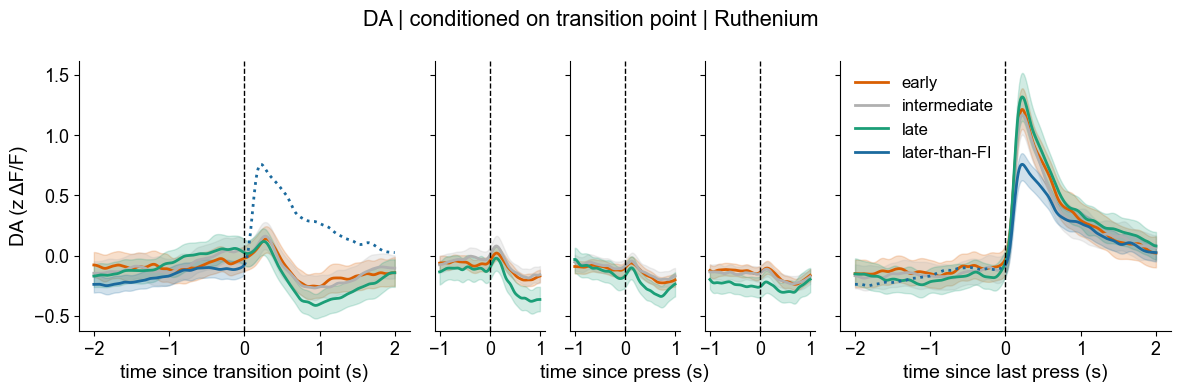

In [75]:
animal = animal1

n_bot = 500

t_4 = np.linspace(-2,2,401)
color_non_transition = '#1b6a9e'
labels = ['early', 'intermediate', 'late', 'later-than-FI']

fig, axs = plt.subplots(1,5, tight_layout = True, figsize = (12,4), width_ratios=[3,1,1,1,3], sharey = True)


df = aggregated_jointdf.query(f'animal == "{animal}"')# and date in {photometry_dates_dict[animal]}')
_, snippets_cp_T1 = compute_snippets_across_days(df,f'bool_cp and tercile_cp_FInormalised == "T1"', 'cp_abs','DA_zscored_session', (-2,2))
_, snippets_cp_T2 = compute_snippets_across_days(df,f'bool_cp and tercile_cp_FInormalised == "T2"', 'cp_abs','DA_zscored_session', (-2,2))
_, snippets_cp_T3 = compute_snippets_across_days(df,f'bool_cp and tercile_cp_FInormalised == "T3"', 'cp_abs','DA_zscored_session', (-2,2))
_, snippets_cp_afterFI = compute_snippets_across_days(df,f'bool_cp == False and count_lever < 3', 'last_lever_abs','DA_zscored_session', (-2,2))
_, snippets_cp_afterFI = compute_snippets_across_days(df,f'bool_cp == False and count_lever == 1', 'last_lever_abs','DA_zscored_session', (-2,2))

all_cp_snippets = [snippets_cp_T1, snippets_cp_T2, snippets_cp_T3]

for ii, snippets in enumerate(all_cp_snippets):
    color = tercile_colors[ii] if ii < 3 else color_non_transition

    median, lower, upper = bootstrap_ci(snippets, n_boot=n_bot, smooth_sigma=5)
    axs[0].plot(t_4, median, color = color, lw = 2, label = labels[ii])
    axs[0].fill_between(t_4, lower, upper, color=color, alpha=0.2)



mask_cp_T1 = (exploded_df['tercile_cp_FInormalised'] == 'T1') & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
mask_cp_T2 = (exploded_df['tercile_cp_FInormalised'] == 'T2') & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
mask_cp_T3 = (exploded_df['tercile_cp_FInormalised'] == 'T3') & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
masks = [mask_cp_T1,mask_cp_T2, mask_cp_T3]

for ii, mask in enumerate(masks):

    color = tercile_colors[ii] if ii < 3 else color_non_transition
    
    median, lower, upper = bootstrap_ci(all_snippets[mask], n_boot=n_bot, smooth_sigma=5)
    axs[-1].plot(t_4, median, color = color, lw = 2, label = labels[ii])
    axs[-1].fill_between(t_4, lower, upper, color=color, alpha=0.2)




## pre lever later-than-FI presses
mask_nocp_trial = (exploded_df['count_lever'] < 3) & (exploded_df['bool_cp'] == False) & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
median_noncp, lower_noncp, upper_noncp = bootstrap_ci(all_snippets[mask_nocp_trial], n_boot=50, smooth_sigma=5)

axs[0].plot(t_4[:200], median_noncp[:200], color = color_non_transition, lw = 2, label = labels[-1])
axs[0].fill_between(t_4[:200], lower_noncp[:200], upper_noncp[:200], color=color_non_transition, alpha=0.2)
axs[0].plot(t_4[200:], median_noncp[200:], color = color_non_transition, lw = 2, ls = ':')

axs[-1].plot(t_4[:200], median_noncp[:200], color = color_non_transition, lw = 2, ls = ':')
axs[-1].plot(t_4[200:], median_noncp[200:], color = color_non_transition, lw = 2, label = labels[-1])
axs[-1].fill_between(t_4[200:], lower_noncp[200:], upper_noncp[200:], color=color_non_transition, alpha=0.2)



## ALIGNMENT LEVER PRESSES: INITIAL TO PRE-TERMINAL
for jj, tercile_category in enumerate(['t1', 't2', 't3']):
    mask_cp_T1 = (exploded_df['tercile_cp_FInormalised'] == 'T1') & (exploded_df['lever_index_category'] == tercile_category) & (exploded_df['animal'] == animal)
    mask_cp_T2 = (exploded_df['tercile_cp_FInormalised'] == 'T2') & (exploded_df['lever_index_category'] == tercile_category) & (exploded_df['animal'] == animal)
    mask_cp_T3 = (exploded_df['tercile_cp_FInormalised'] == 'T3') & (exploded_df['lever_index_category'] == tercile_category) & (exploded_df['animal'] == animal)
    masks = [mask_cp_T1,mask_cp_T2, mask_cp_T3]

    for ii, mask in enumerate(masks):
        color = tercile_colors[ii] if ii < 3 else color_non_transition
        median, lower, upper = bootstrap_ci(all_snippets[mask], n_boot=n_bot, smooth_sigma=5)
        axs[1+jj].plot(t_4[100:-100], median[100:-100], color = color, lw = 2, label = labels[ii])
        axs[1+jj].fill_between(t_4[100:-100], lower[100:-100], upper[100:-100], color=color, alpha=0.2)


axs[-1].legend(frameon = False, fontsize = 12)

axs[0].set_xlabel('time since transition point (s)')
axs[2].set_xlabel('time since press (s)')
axs[-1].set_xlabel('time since last press (s)')

[axs[ii].axvline(0,color = 'black', ls = '--', lw = 1) for ii in range(5)]

axs[0].set_ylabel('DA (z ΔF/F)')

figtitle = f'DA | conditioned on transition point | {animal}'

plt.suptitle(figtitle)
#plt.savefig(rf'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace("|","_")}.png')

In [ ]:

## same as above but split by experiment

animal = animal2
exp = 'c'

n_bot = 500

t_4 = np.linspace(-2,2,401)
color_non_transition = '#1b6a9e'
labels = ['early', 'intermediate', 'late', 'later-than-FI']

fig, axs = plt.subplots(1,5, tight_layout = True, figsize = (12,4), width_ratios=[3,1,1,1,3], sharey = True)


df = aggregated_jointdf.query(f'animal == "{animal}" and experiment == "{exp}"')# and date in {photometry_dates_dict[animal]}')
_, snippets_cp_T1 = compute_snippets_across_days(df,f'bool_cp and tercile_cp_FInormalised == "T1"', 'cp_abs','DA_zscored_session', (-2,2))
_, snippets_cp_T2 = compute_snippets_across_days(df,f'bool_cp and tercile_cp_FInormalised == "T2"', 'cp_abs','DA_zscored_session', (-2,2))
_, snippets_cp_T3 = compute_snippets_across_days(df,f'bool_cp and tercile_cp_FInormalised == "T3"', 'cp_abs','DA_zscored_session', (-2,2))
_, snippets_cp_afterFI = compute_snippets_across_days(df,f'bool_cp == False and count_lever < 3', 'last_lever_abs','DA_zscored_session', (-2,2))
_, snippets_cp_afterFI = compute_snippets_across_days(df,f'bool_cp == False and count_lever == 1', 'last_lever_abs','DA_zscored_session', (-2,2))

all_cp_snippets = [snippets_cp_T1, snippets_cp_T2, snippets_cp_T3]

for ii, snippets in enumerate(all_cp_snippets):
    color = tercile_colors[ii] if ii < 3 else color_non_transition

    median, lower, upper = bootstrap_ci(snippets, n_boot=n_bot, smooth_sigma=5)
    axs[0].plot(t_4, median, color = color, lw = 2, label = labels[ii])
    axs[0].fill_between(t_4, lower, upper, color=color, alpha=0.2)



mask_cp_T1 = (exploded_df['experiment'] == exp) & (exploded_df['tercile_cp_FInormalised'] == 'T1') & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
mask_cp_T2 = (exploded_df['experiment'] == exp) & (exploded_df['tercile_cp_FInormalised'] == 'T2') & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
mask_cp_T3 = (exploded_df['experiment'] == exp) & (exploded_df['tercile_cp_FInormalised'] == 'T3') & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
masks = [mask_cp_T1,mask_cp_T2, mask_cp_T3]

for ii, mask in enumerate(masks):

    color = tercile_colors[ii] if ii < 3 else color_non_transition
    
    median, lower, upper = bootstrap_ci(all_snippets[mask], n_boot=n_bot, smooth_sigma=5)
    axs[-1].plot(t_4, median, color = color, lw = 2, label = labels[ii])
    axs[-1].fill_between(t_4, lower, upper, color=color, alpha=0.2)




## pre lever later-than-FI presses
mask_nocp_trial = (exploded_df['count_lever'] < 3) & (exploded_df['bool_cp'] == False) & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
median_noncp, lower_noncp, upper_noncp = bootstrap_ci(all_snippets[mask_nocp_trial], n_boot=50, smooth_sigma=5)

axs[0].plot(t_4[:200], median_noncp[:200], color = color_non_transition, lw = 2, label = labels[-1])
axs[0].fill_between(t_4[:200], lower_noncp[:200], upper_noncp[:200], color=color_non_transition, alpha=0.2)
axs[0].plot(t_4[200:], median_noncp[200:], color = color_non_transition, lw = 2, ls = ':')

axs[-1].plot(t_4[:200], median_noncp[:200], color = color_non_transition, lw = 2, ls = ':')
axs[-1].plot(t_4[200:], median_noncp[200:], color = color_non_transition, lw = 2, label = labels[-1])
axs[-1].fill_between(t_4[200:], lower_noncp[200:], upper_noncp[200:], color=color_non_transition, alpha=0.2)



## ALIGNMENT LEVER PRESSES: INITIAL TO PRE-TERMINAL
for jj, tercile_category in enumerate(['t1', 't2', 't3']):
    mask_cp_T1 = (exploded_df['experiment'] == exp) & (exploded_df['tercile_cp_FInormalised'] == 'T1') & (exploded_df['lever_index_category'] == tercile_category) & (exploded_df['animal'] == animal)
    mask_cp_T2 = (exploded_df['experiment'] == exp) & (exploded_df['tercile_cp_FInormalised'] == 'T2') & (exploded_df['lever_index_category'] == tercile_category) & (exploded_df['animal'] == animal)
    mask_cp_T3 = (exploded_df['experiment'] == exp) & (exploded_df['tercile_cp_FInormalised'] == 'T3') & (exploded_df['lever_index_category'] == tercile_category) & (exploded_df['animal'] == animal)
    masks = [mask_cp_T1,mask_cp_T2, mask_cp_T3]

    for ii, mask in enumerate(masks):
        color = tercile_colors[ii] if ii < 3 else color_non_transition
        median, lower, upper = bootstrap_ci(all_snippets[mask], n_boot=n_bot, smooth_sigma=5)
        axs[1+jj].plot(t_4[100:-100], median[100:-100], color = color, lw = 2, label = labels[ii])
        axs[1+jj].fill_between(t_4[100:-100], lower[100:-100], upper[100:-100], color=color, alpha=0.2)


axs[-1].legend(frameon = False, fontsize = 12)

axs[0].set_xlabel('time since transition point (s)')
axs[2].set_xlabel('time since press (s)')
axs[-1].set_xlabel('time since last press (s)')

[axs[ii].axvline(0,color = 'black', ls = '--', lw = 1) for ii in range(5)]

axs[0].set_ylabel('DA (z ΔF/F)')

figtitle = f'DA | conditioned on transition point | {animal} | experiment {exp}'

plt.suptitle(figtitle)
#plt.savefig(rf'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace("|","_")}.png')

## all conds (not from the thesis nb)

Text(0.5, 0.98, 'DA | conditioned on transition point | Palladium | per block type within experimental condition')

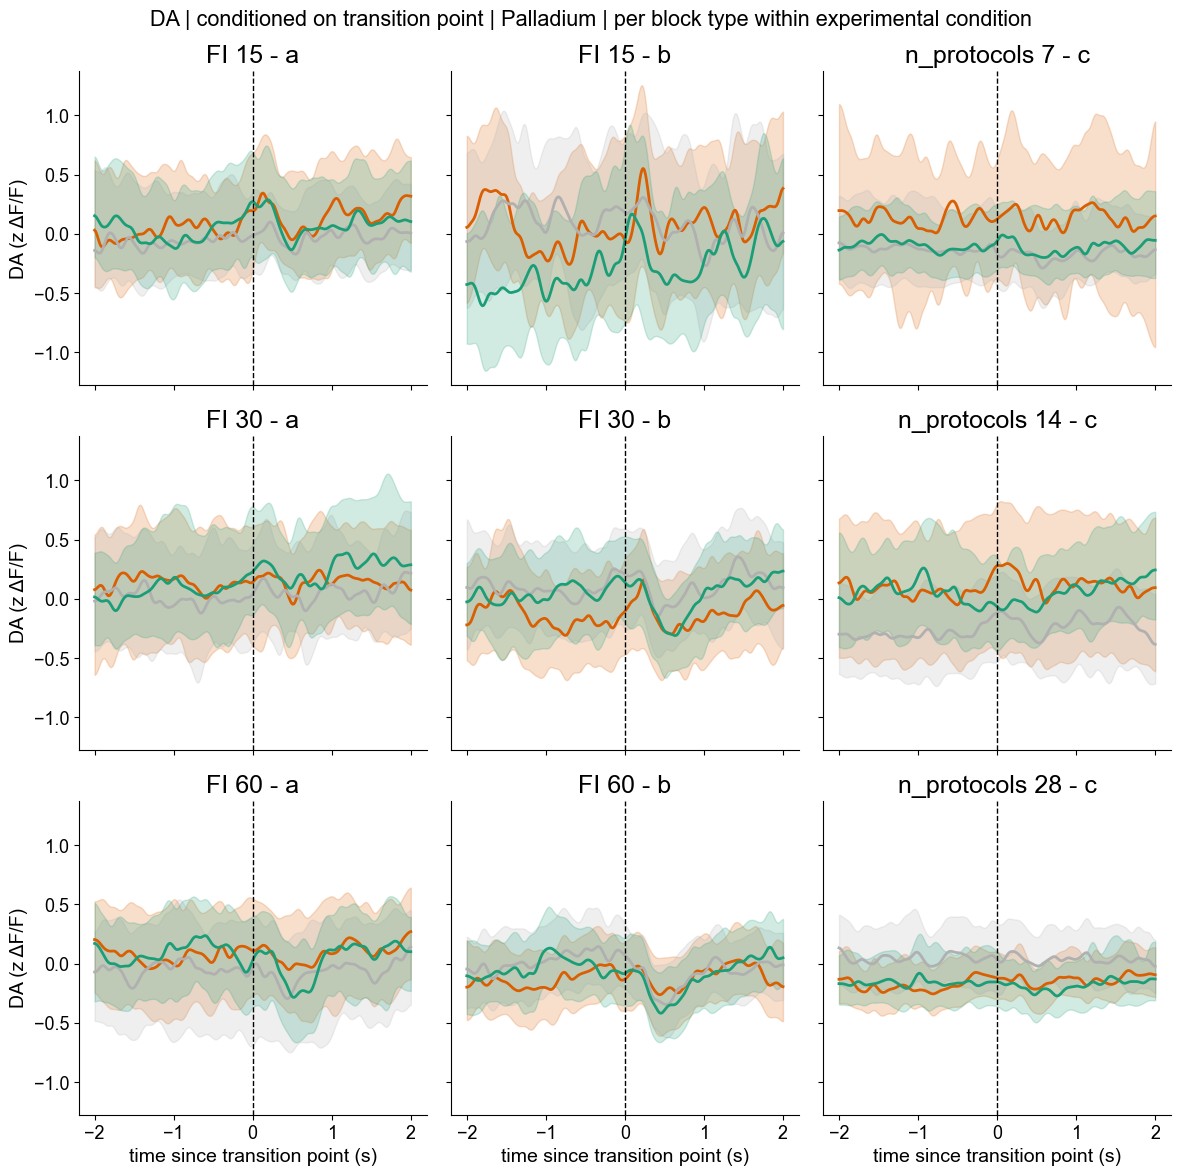

In [76]:

"""
....###....##.......##...........######...#######..##....##.########...######.
...##.##...##.......##..........##....##.##.....##.###...##.##.....##.##....##
..##...##..##.......##..........##.......##.....##.####..##.##.....##.##......
.##.....##.##.......##..........##.......##.....##.##.##.##.##.....##..######.
.#########.##.......##..........##.......##.....##.##..####.##.....##.......##
.##.....##.##.......##..........##....##.##.....##.##...###.##.....##.##....##
.##.....##.########.########.....######...#######..##....##.########...######.

not from the thesis nb -- split by conditions: block types within experiment types

"""
animal = animal2

alignment = 'cp_abs'
alignment_label = 'transition point'
#alignment = 'last_lever_abs'
#alignment_label = 'last press'

fig, axs = plt.subplots(3,3, tight_layout = True, figsize = (12,12), sharex = True, sharey = True)

for jj, exp in enumerate(['a','b','c']):
    if exp == 'c':
        variable = 'n_protocols'
        order = rwd_order
    else:
        variable = 'FI'
        order = FI_order

    for kk, var in enumerate(order):
        df = aggregated_jointdf.query(f'animal == "{animal}" and experiment == "{exp}" and {variable} == {var}')
        _, snippets_cp_T1 = compute_snippets_across_days(df,f'bool_cp and tercile_cp_FInormalised == "T1"', alignment,'DA_zscored_session', (-2,2))
        _, snippets_cp_T2 = compute_snippets_across_days(df,f'bool_cp and tercile_cp_FInormalised == "T2"', alignment,'DA_zscored_session', (-2,2))
        _, snippets_cp_T3 = compute_snippets_across_days(df,f'bool_cp and tercile_cp_FInormalised == "T3"', alignment,'DA_zscored_session', (-2,2))
        #_, snippets_cp_afterFI = compute_snippets_across_days(df,f'bool_cp == False and count_lever < 3', 'last_lever_abs','DA_zscored_session', (-2,2))
        #_, snippets_cp_afterFI = compute_snippets_across_days(df,f'bool_cp == False and count_lever == 1', 'last_lever_abs','DA_zscored_session', (-2,2))

        all_cp_snippets = [snippets_cp_T1, snippets_cp_T2, snippets_cp_T3]

        for ii, snippets in enumerate(all_cp_snippets):
            color = tercile_colors[ii] if ii < 3 else color_non_transition

            median, lower, upper = bootstrap_ci(snippets, n_boot=n_bot, smooth_sigma=5)
            axs[kk,jj].plot(t_4, median, color = color, lw = 2, label = labels[ii])
            axs[kk,jj].fill_between(t_4, lower, upper, color=color, alpha=0.2)

        axs[kk,jj].set_title(f'{variable} {var} - {exp}')
        axs[kk,jj].axvline(0,color = 'black', ls = '--', lw = 1)

        axs[kk,0].set_ylabel('DA (z ΔF/F)')

    axs[-1,jj].set_xlabel(f'time since {alignment_label} (s)')


figtitle = f'DA | conditioned on {alignment_label} | {animal} | per block type within experimental condition'

plt.suptitle(figtitle)
#plt.savefig(rf'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace("|","_")}.png')


Text(0.5, 0.98, 'Ruthenium | experiment b | DA within trial sorted by transition point')

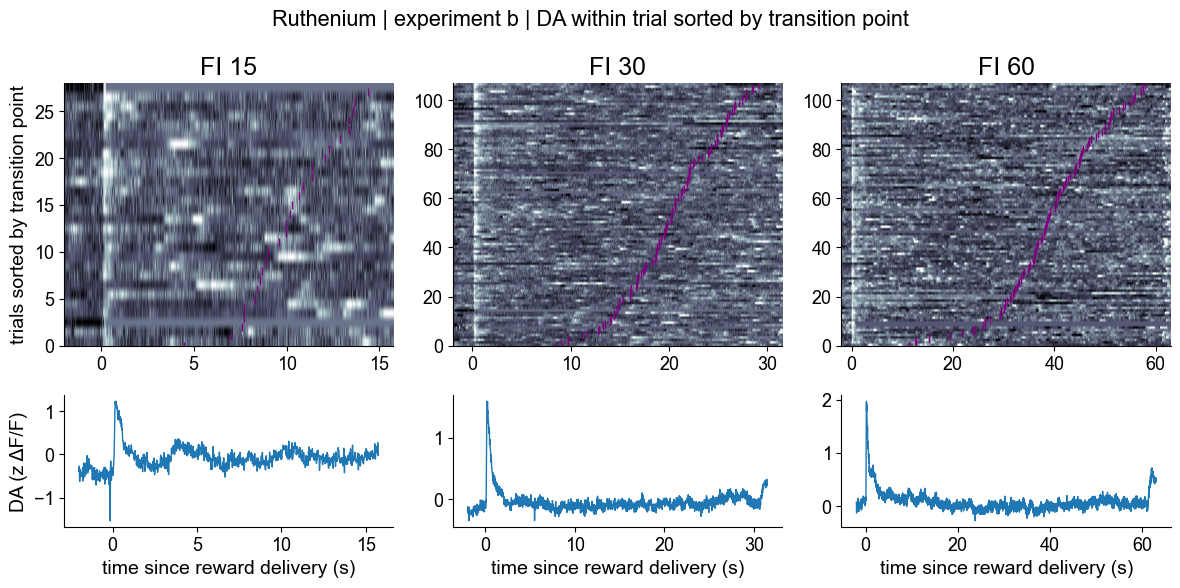

In [77]:

animal = 'Ruthenium'
exp = 'b'

if exp == "c":
    var = 'n_protocols'
    order = rwd_order
else:
    var = 'FI'
    order = FI_order


fig, axs = plt.subplots(2,3, tight_layout = True, figsize = (12,6), height_ratios = [2,1])#, width_ratios=[1,2,4])

for ii, cond in enumerate(order):

    df = aggregated_jointdf.query(f'animal == "{animal}" and experiment == "{exp}" and {var} == {cond}')
    
    FI = 30 if exp == 'c' else cond
    ## nanify False is not working, halp! -- something weird is going on with the nanify and delta_t; might need to restart stuff
    t_long, snippets_long = compute_snippets_across_days(df,
        'FI > 0', 'last_lever_abs', 'DA_zscored_session', (-2,FI*1.05))

    cps = df.cp.values
    sorted_cps = cps[np.argsort(cps)]
    #next_rwd = aggregated_jointdf.query('bool_cp and animal == "Ruthenium" and experiment == "a" and FI == 30').apply(lambda x: x.cp_abs - x.trial_start, axis = 1).values

    data = snippets_long[np.argsort(cps)][~np.isnan(sorted_cps)]

    #plot_snippets(data, t_long, axs[0,ii], axs[1,ii])

    vmin,vmax = np.nanquantile(data, [.01,.99])
    axs[0,ii].imshow(zscore(data, axis = 1), aspect = 'auto', vmin = vmin, vmax = vmax,
               extent = [t_long[0],t_long[-1],0,len(data)], origin = 'lower', cmap = 'bone')
    axs[0,ii].plot(sorted_cps, np.arange(0,len(cps)), '|', color = 'purple')
    axs[1,ii].plot(t_long, np.nanmean(data, axis = 0), lw = 1)
    #axs[1,ii].plot(t_long, np.nanmean(zscore(data, axis = 1), axis = 0))

    axs[0,ii].set_title(f'{var} {cond}')

axs[0,0].set_ylabel('trials sorted by transition point')
axs[1,0].set_ylabel('DA (z ΔF/F)')

[axs[1,ii].set_xlabel('time since reward delivery (s)') for ii in range(3)]

figtitle = f'{animal} | experiment {exp} | DA within trial sorted by transition point'

plt.suptitle(figtitle)
#plt.savefig(rf'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace("|","_")}.png')

## something else

Text(0.5, 0.98, 'DA | Palladium | around lever presses | split per experimental condition')

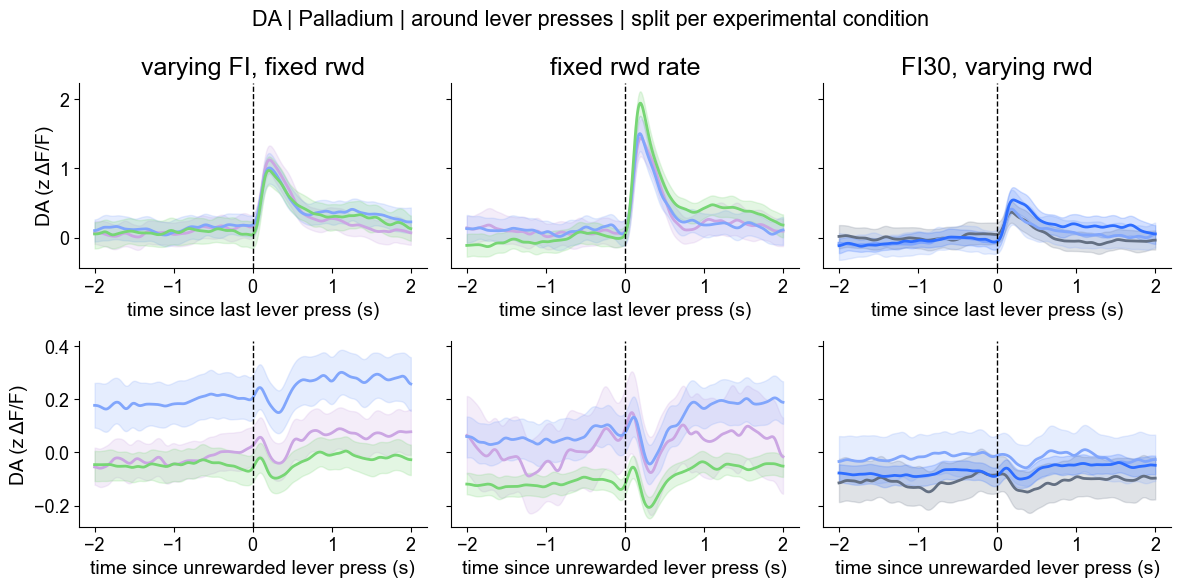

In [78]:

"""
..######..########..##.......####.########....########..##....##....########.##.....##.########..########.########..####.##.....##.########.##....##.########....###....##...........######...#######..##....##.########..####.########.####..#######..##....##..######.
.##....##.##.....##.##........##.....##.......##.....##..##..##.....##........##...##..##.....##.##.......##.....##..##..###...###.##.......###...##....##......##.##...##..........##....##.##.....##.###...##.##.....##..##.....##.....##..##.....##.###...##.##....##
.##.......##.....##.##........##.....##.......##.....##...####......##.........##.##...##.....##.##.......##.....##..##..####.####.##.......####..##....##.....##...##..##..........##.......##.....##.####..##.##.....##..##.....##.....##..##.....##.####..##.##......
..######..########..##........##.....##.......########.....##.......######......###....########..######...########...##..##.###.##.######...##.##.##....##....##.....##.##..........##.......##.....##.##.##.##.##.....##..##.....##.....##..##.....##.##.##.##..######.
.......##.##........##........##.....##.......##.....##....##.......##.........##.##...##........##.......##...##....##..##.....##.##.......##..####....##....#########.##..........##.......##.....##.##..####.##.....##..##.....##.....##..##.....##.##..####.......##
.##....##.##........##........##.....##.......##.....##....##.......##........##...##..##........##.......##....##...##..##.....##.##.......##...###....##....##.....##.##..........##....##.##.....##.##...###.##.....##..##.....##.....##..##.....##.##...###.##....##
..######..##........########.####....##.......########.....##.......########.##.....##.##........########.##.....##.####.##.....##.########.##....##....##....##.....##.########.....######...#######..##....##.########..####....##....####..#######..##....##..######.
"""

animal = animal2

t_4 = np.linspace(-2,2,401)


fig, axs = plt.subplots(2,3, tight_layout = True, figsize = (12,6), sharey = 'row')

for ii,FI in enumerate(FI_order):
    cond_color = color_FI_blocks[ii]

    ## a
    cond_mask = (exploded_df['experiment'] == 'a') & (exploded_df['FI'] == FI) & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
    median, lower, upper = bootstrap_ci(all_snippets[cond_mask], n_boot=500, smooth_sigma=5)
    axs[0,0].plot(t_4, median, color = cond_color, lw = 2)
    axs[0,0].fill_between(t_4, lower, upper, color=cond_color, alpha=0.2)

    cond_mask = (exploded_df['experiment'] == 'a') & (exploded_df['FI'] == FI) & (exploded_df['lever_index'] != -1) & (exploded_df['animal'] == animal)
    median, lower, upper = bootstrap_ci(all_snippets[cond_mask], n_boot=500, smooth_sigma=5)
    axs[1,0].plot(t_4, median, color = cond_color, lw = 2)
    axs[1,0].fill_between(t_4, lower, upper, color=cond_color, alpha=0.2)

    ## b
    cond_mask = (exploded_df['experiment'] == 'b') & (exploded_df['FI'] == FI) & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
    median, lower, upper = bootstrap_ci(all_snippets[cond_mask], n_boot=500, smooth_sigma=5)
    axs[0,1].plot(t_4, median, color = cond_color, lw = 2)
    axs[0,1].fill_between(t_4, lower, upper, color=cond_color, alpha=0.2)

    cond_mask = (exploded_df['experiment'] == 'b') & (exploded_df['FI'] == FI) & (exploded_df['lever_index'] != -1) & (exploded_df['animal'] == animal)
    median, lower, upper = bootstrap_ci(all_snippets[cond_mask], n_boot=500, smooth_sigma=5)
    axs[1,1].plot(t_4, median, color = cond_color, lw = 2)
    axs[1,1].fill_between(t_4, lower, upper, color=cond_color, alpha=0.2)

for ii, rwd in enumerate(rwd_order): ## c
    cond_color = color_rwd_blocks[ii]

    cond_mask = (exploded_df['experiment'] == 'c') & (exploded_df['n_protocols'] == rwd) & (exploded_df['lever_index'] == -1) & (exploded_df['animal'] == animal)
    median, lower, upper = bootstrap_ci(all_snippets[cond_mask], n_boot=500, smooth_sigma=5)
    axs[0,2].plot(t_4, median, color = cond_color, lw = 2)
    axs[0,2].fill_between(t_4, lower, upper, color=cond_color, alpha=0.2)

    cond_mask = (exploded_df['experiment'] == 'c') & (exploded_df['n_protocols'] == rwd) & (exploded_df['lever_index'] != -1) & (exploded_df['animal'] == animal)
    median, lower, upper = bootstrap_ci(all_snippets[cond_mask], n_boot=500, smooth_sigma=5)
    axs[1,2].plot(t_4, median, color = cond_color, lw = 2)
    axs[1,2].fill_between(t_4, lower, upper, color=cond_color, alpha=0.2)

for kk in range(2):
    axs[kk,0].set_ylabel('DA (z ΔF/F)')

    for jj in range(3):    
        axs[kk,jj].axvline(0,color = 'black', ls = '--', lw = 1)

for jj in range(3):
    axs[0,jj].set_xlabel(f'time since last lever press (s)')
    axs[1,jj].set_xlabel(f'time since unrewarded lever press (s)')


axs[0,0].set_title('varying FI, fixed rwd')
axs[0,1].set_title('fixed rwd rate')
axs[0,2].set_title('FI30, varying rwd')


figtitle = f'DA | {animal} | around lever presses | split per experimental condition'

plt.suptitle(figtitle)
#plt.savefig(rf'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace("|","_")}.png')


skipped the new snippets

In [ ]:
## this in principle should be the same as above; and it is!! I had a bug above in which I was filtering the exploded_df to account only for exp c
"""
.##....##.########.##......##.....######..##....##.####.########..########..########.########..######.
.###...##.##.......##..##..##....##....##.###...##..##..##.....##.##.....##.##..........##....##....##
.####..##.##.......##..##..##....##.......####..##..##..##.....##.##.....##.##..........##....##......
.##.##.##.######...##..##..##.....######..##.##.##..##..########..########..######......##.....######.
.##..####.##.......##..##..##..........##.##..####..##..##........##........##..........##..........##
.##...###.##.......##..##..##....##....##.##...###..##..##........##........##..........##....##....##
.##....##.########..###..###......######..##....##.####.##........##........########....##.....######.
"""
# Define your columns
colname = 'DA_session_zscored'
eventalignment = 'nonrwd_lever_abs'
## ['cp_abs','nonrwd_lever_abs','rwd_lever_abs']

# Storage for snippets and metadata arrays
all_snipps = []
meta = {
    'animal': [], 'date': [], 'experiment': [], 'FI': [], 'n_protocols': []
}

# Group by all 5 metadata factors
meta_cols = ['animal', 'date', 'experiment', 'FI', 'n_protocols']  # Adjust 'n_protocols' if your column name is different

for (ani, date, exp, fi, rwd), daydf in aggregated_jointdf.groupby(meta_cols):
    
    ts = np.hstack(daydf.timestamp_session.values)
    sig = np.hstack(daydf[colname].values)
    
    evs = np.hstack([np.atleast_1d(x) for x in daydf[eventalignment].values])
    
    snipps, time = signal2eventsnippets(ts, sig, evs, [-4, 4], 0.01)
    
    num_snipps = snipps.shape[0]
    if num_snipps > 0:
        all_snipps.append(snipps)
        
        meta['animal'].append(np.full(num_snipps, ani))
        meta['date'].append(np.full(num_snipps, date))
        meta['experiment'].append(np.full(num_snipps, exp))
        meta['FI'].append(np.full(num_snipps, fi))
        meta['n_protocols'].append(np.full(num_snipps, rwd))

snipps_matrix = np.vstack(all_snipps)
animal_idx = np.concatenate(meta['animal'])
date_idx = np.concatenate(meta['date'])
exp_idx = np.concatenate(meta['experiment'])
FI_idx = np.concatenate(meta['FI'])
rwd_idx = np.concatenate(meta['n_protocols'])

snipps_matrix = drop_nans_matrix(snipps_matrix)

#%%

nonrwd_snipps_Pa = snipps_matrix
#rwd_snipps_Pa = snipps_matrix
#%%

## not sure where exp_list is defined, but it's part of the globals somewhere

fig, axs = plt.subplots(1,3, figsize = (12,4), tight_layout = True, sharey = True)

for ii, exp in enumerate(exp_list):
    if exp != 'c':
        for jj, FI in enumerate(FI_order):
            mask = (animal_idx == animal) & (exp_idx == exp) & (FI_idx == FI)
            subset = snipps_matrix[mask]

            axs[ii].plot(time, np.nanmean(subset, axis = 0), color = color_FI_blocks[jj])
    else:
        for jj, rwd in enumerate(rwd_order):
            mask = (animal_idx == animal) & (exp_idx == exp) & (rwd_idx == rwd)
            subset = snipps_matrix[mask]

            axs[ii].plot(time, np.nanmean(subset, axis = 0), color = color_rwd_blocks[jj])

    axs[ii].axvline(0, ls = '--', color = 'grey')
    axs[ii].set_title(f'experiment {exp}')
    axs[ii].set_xlabel('time since last lever press (s)')

axs[0].set_ylabel('av. DA across sessions (dF/F)')

figtitle = f'{animal} | all sessions aggregated | channel {colname} aligned to {eventalignment}'
plt.suptitle(figtitle)

plt.savefig(rf'{PATH_SAVE_DFS}\{figtitle.replace("|","_")}.png', dpi = 300)
#%%

fig, axs = plt.subplots(1,2, tight_layout = True, figsize = (8,4), sharey = True)

axs[0].plot(time, np.nanmean(nonrwd_snipps_Ru, axis = 0))
axs[0].plot(time, np.nanmean(rwd_snipps_Ru, axis = 0))

axs[1].plot(time, np.nanmean(nonrwd_snipps_Pa, axis = 0))
axs[1].plot(time, np.nanmean(rwd_snipps_Pa, axis = 0))

for ii in range(2):
    axs[ii].axvline(0, ls = '--', color = 'grey')
#%%
from matplotlib import cm

fig, axs = plt.subplots(3,2, tight_layout = True, figsize = (8,8), sharex = True)

lvr_rwd_labels = ['nonrwd', 'rwd']
bone_cmap = cm.get_cmap('bone')
lvr_rwd_colors = [bone_cmap(0.7), bone_cmap(0.2)]

for ii,data in enumerate([nonrwd_snipps_Ru, rwd_snipps_Ru, nonrwd_snipps_Pa, rwd_snipps_Pa]):

    data_z = zscore(data, axis = 1)
    vmin = np.nanquantile(data_z, .05)
    vmax = np.nanquantile(data_z, .95)
    axs[ii%2,int(ii/2)].imshow(data_z, aspect = 'auto', vmin = vmin, vmax = vmax, cmap = 'bone', origin = 'lower',
               extent = [time[0], time[-1], 0, data.shape[0]])

    axs[-1,int(ii/2)].plot(time, np.nanmean(data, axis = 0), label = lvr_rwd_labels[ii%2], color = lvr_rwd_colors[ii%2])

for ii in range(2):   
    axs[-1,ii].axvline(0, ls = '--', color = 'grey')
    axs[-1,ii].set_xlabel('time since lever press (s)')

axs[-1,0].legend(frameon = False)

axs[0,0].set_title('Ruthenium')
axs[0,1].set_title('Palladium')

axs[0,0].set_ylabel('non-rewarded')
axs[1,0].set_ylabel('rewarded')
axs[2,0].set_ylabel('av. DA on lever presses')

figtitle = 'DA aligned to lever presses | rewarded vs unrewarded'
plt.suptitle(figtitle)

plt.savefig(rf'{PATH_SAVE_DFS}\{figtitle.replace("|","_")}.png', dpi = 300)

#axs[1,1].imshow(rwd_snipps_Ru, aspect = 'auto', vmin = np.nanquantile(rwd_snipps_Ru, .05), vmax = np.nanquantile(rwd_snipps_Ru, .95), cmap = 'bone', origin = 'lower',
#           extent = [time[0], time[-1], 0, rwd_snipps_Ru.shape[0]])

#%%


## click and DA

Looking specifically at the last few sessions of the animals, in which the click is introduced

Not sure what to expect from this fig up here, just randomly plotted this... the actual order of presenting stuff should be:
- daily effect of the click, i.e. how the progressive exposure to the click affects the DA response. the expectation is that as the cue becomes less novel, DA transient at click will lower
- interaction between click and rwd response. do we see any effect in the magnitude of the response to the reward with the progressive delivery of the click? (and maybe we need to do this paired within trial)
- the fig above is actually interesting as well, in particular when aligning on the click: is the click more surprising when there haven't been any presses yet? (from the fig above it doesnt seem to be the case but we're also not controlling for factors like FI and if it's right after a block transition)
- block transitions -- prediction is that response at click is accompanied by the 
- responses at click for the different FI: less temporal uncertainty = smaller response? (i.e. responses at FI15 < FI30 < FI60)

In [ ]:
time, snippets_click, meta_click = compute_snippets_across_sessions(aggregated_jointdf,'FI > 0', 'click_on_abs','DA_zscored_session', (-4,4))

## assuming the other alignments have already been computed at the beginning of the notebook. if not, uncomment these lines :)

#time, snippets_cp, meta_cp = compute_snippets_across_sessions(aggregated_jointdf,f'bool_cp', 'cp_abs','DA_zscored_session', (-4,4))
#time, snippets_last, meta_last = compute_snippets_across_sessions(aggregated_jointdf,'FI > 0', 'last_lever_abs','DA_zscored_session', (-4,4))


Text(0.5, 0.98, 'Palladium | DA aligned to clicks and lever presses | transition vs no transition trials')

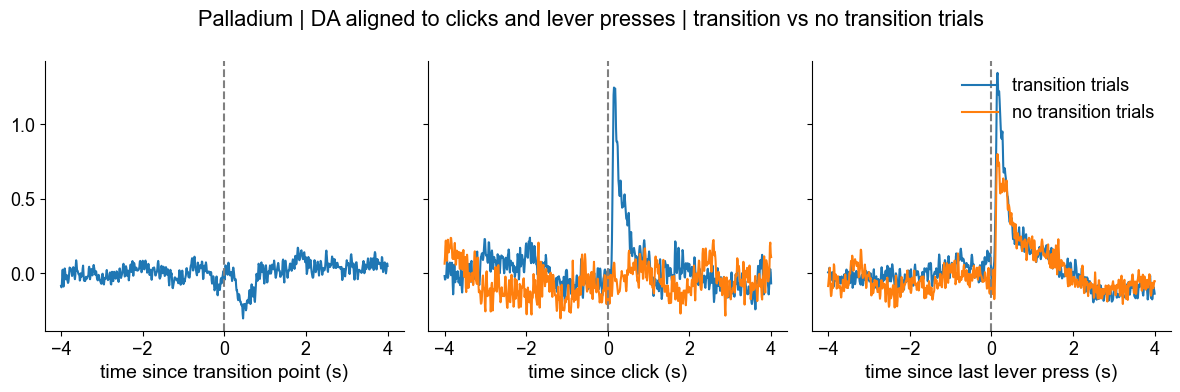

In [260]:
animal = 'Palladium'

fig, axs = plt.subplots(1,3, tight_layout = True, figsize = (12,4), sharey = True)

axs[0].plot(time, np.nanmean(snippets_cp[
    meta_cp[(meta_cp['FI'] == 60) & (meta_cp['experiment'] == "a") & (meta_cp['animal'] == animal)].index, :],
    axis = 0))

axs[1].plot(time, np.nanmean(snippets_click[
    meta_click[(meta_click['bool_cp'] == True) & (meta_click['FI'] == 60) & (meta_click['experiment'] == "a") & (meta_click['animal'] == animal)].index, :],
    axis = 0))
axs[1].plot(time, np.nanmean(snippets_click[
    meta_click[(meta_click['bool_cp'] == False) & (meta_click['FI'] == 60) & (meta_click['experiment'] == "a") & (meta_click['animal'] == animal)].index, :],
    axis = 0))

axs[2].plot(time, np.nanmean(snippets_last[
    meta_last[(meta_last['bool_cp'] == True) & (meta_last['FI'] == 60) & (meta_last['experiment'] == "a") & (meta_last['animal'] == animal)].index, :],
    axis = 0),
    label = 'transition trials')
axs[2].plot(time, np.nanmean(snippets_last[
    meta_last[(meta_last['bool_cp'] == False) & (meta_last['bool_cp'] == False) & (meta_last['FI'] == 60) & (meta_last['experiment'] == "a") & (meta_last['animal'] == animal)].index, :],
    axis = 0), 
    label = 'no transition trials')


axs[2].legend(frameon = False)
[axs[ii].axvline(0, ls = '--', color = 'grey') for ii in range(3)]

axs[0].set_xlabel('time since transition point (s)')
axs[1].set_xlabel('time since click (s)')
axs[2].set_xlabel('time since last lever press (s)')

figtitle = f'{animal} | DA aligned to clicks and lever presses | transition vs no transition trials'
plt.suptitle(figtitle)

C:\Users\Admin\AppData\Local\Temp\ipykernel_1824\2846330995.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(rf'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace("|","_")}.png', dpi = 300)
c:\Users\Admin\anaconda3\envs\neuro\Lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
c:\Users\Admin\anaconda3\envs\neuro\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


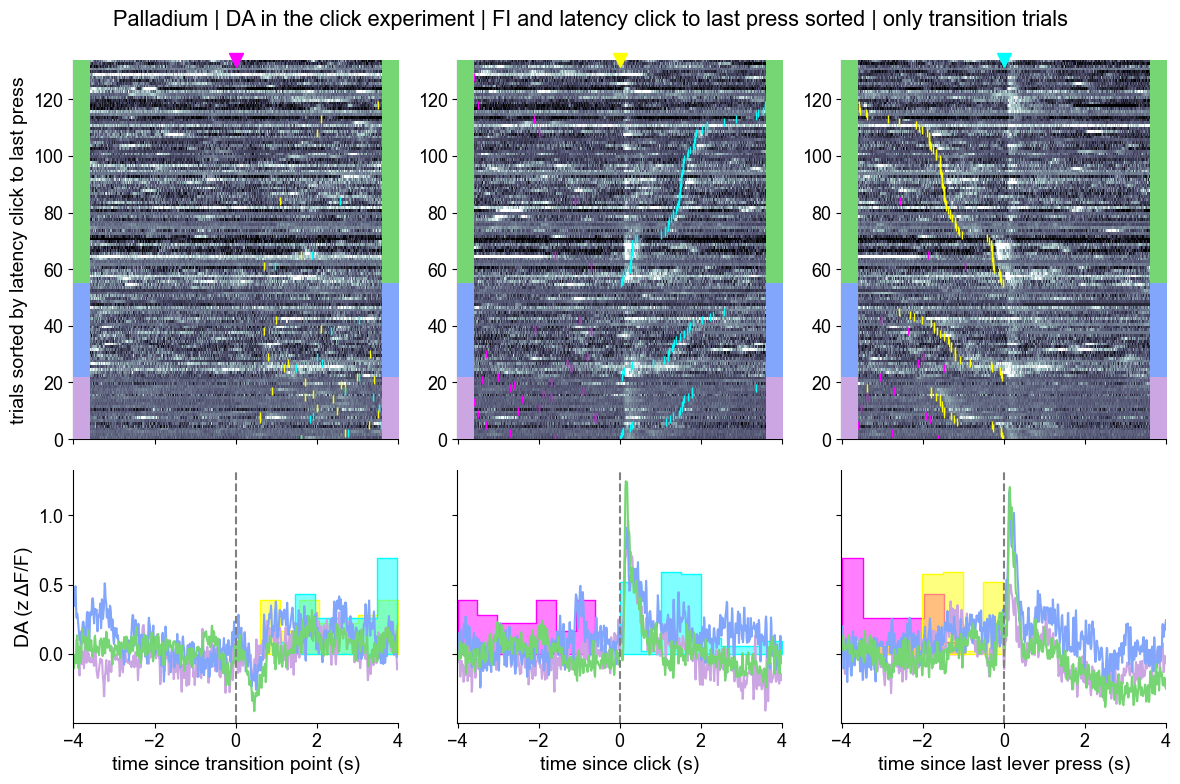

In [ ]:
animal = 'Palladium'

fig, axs = plt.subplots(2,3, tight_layout = True, figsize = (12,8), sharex = 'col', height_ratios=[3,2])

cp_color = 'magenta'
click_color = 'yellow'
last_color = 'cyan'

for col in range(1, 3):
    axs[1, col].sharey(axs[1, 0])
    axs[1, col].tick_params(labelleft=False) # Hide labels

## aligned to the transition point

mask = (meta_cp['bool_cp'] == True) & \
       (meta_cp['click'] == True) & \
       (meta_cp['animal'] == animal)

sorted_meta = meta_cp[mask].sort_values(by=['FI', 'latency_click_to_last_lever'])
sorted_snippets = snippets_cp[sorted_meta.index, :]

plot_snippets(sorted_snippets, time, axs[0,0], axs[1,0], cmap = 'bone', bool_plot_mean=False)

for ii, FI in enumerate(FI_order):
    cond_color = color_FI_blocks[ii]
    mask_FI = (sorted_meta['FI'] == FI)
    mean_signal = np.nanmean(sorted_snippets[mask_FI, :], axis=0)
    axs[1,0].plot(time, mean_signal, color=cond_color)

# annotate in the heatmap where the other events are
click_times = (sorted_meta.click_on_abs - sorted_meta.cp_abs).values
click_times_idx = click_times < time[-1]
axs[0,0].plot(click_times[click_times_idx], np.arange(0,len(sorted_meta))[click_times_idx], '|', color = click_color)

last_times = (sorted_meta.last_lever_abs - sorted_meta.cp_abs).values
last_times_idx = last_times < time[-1]
axs[0,0].plot(last_times[last_times_idx], np.arange(0,len(sorted_meta))[last_times_idx], '|', color = last_color)

sns.histplot(click_times[click_times_idx], ax=axs[1,0], color = click_color, element = 'step', stat = 'density', alpha = 0.5)
sns.histplot(last_times[last_times_idx], ax=axs[1,0], color = last_color, element = 'step', stat = 'density', alpha = 0.5)

FI_values = sorted_meta['FI'].values
for loc in ['center left', 'center right']:
    ax_FI = inset_axes(axs[0,0], width="5%", height="100%", loc=loc, borderpad=0)
    ax_FI.matshow(FI_values.reshape(len(FI_values),1), aspect = 'auto', cmap = cmap_FI, origin = 'lower')
    ax_FI.set_axis_off()


## aligned to the click event

mask = (meta_click['bool_cp'] == True) & \
       (meta_click['click'] == True) & \
       (meta_click['animal'] == animal)

sorted_meta = meta_click[mask].sort_values(by=['FI', 'latency_click_to_last_lever'])
sorted_snippets = snippets_click[sorted_meta.index, :]

plot_snippets(sorted_snippets, time, axs[0,1], axs[1,1], cmap = 'bone', bool_plot_mean=False)

for ii, FI in enumerate(FI_order):
    cond_color = color_FI_blocks[ii]
    mask_FI = (sorted_meta['FI'] == FI)
    mean_signal = np.nanmean(sorted_snippets[mask_FI, :], axis=0)
    axs[1,1].plot(time, mean_signal, color=cond_color)

# annotate in the heatmap where the other events are
cp_times = (sorted_meta.cp_abs - sorted_meta.click_on_abs).values
cp_times_idx = cp_times > time[0]
axs[0,1].plot(cp_times[cp_times_idx], np.arange(0,len(sorted_meta))[cp_times_idx], '|', color = cp_color)

last_times = (sorted_meta.last_lever_abs - sorted_meta.click_on_abs).values
last_times_idx = last_times < time[-1]
axs[0,1].plot(last_times[last_times_idx], np.arange(0,len(sorted_meta))[last_times_idx], '|', color = last_color)

sns.histplot(cp_times[cp_times_idx], ax=axs[1,1], color = cp_color, element = 'step', stat = 'density', alpha = 0.5)
sns.histplot(last_times[last_times_idx], ax=axs[1,1], color = last_color, element = 'step', stat = 'density', alpha = 0.5)

FI_values = sorted_meta['FI'].values
for loc in ['center left', 'center right']:
    ax_FI = inset_axes(axs[0,1], width="5%", height="100%", loc=loc, borderpad=0)
    ax_FI.matshow(FI_values.reshape(len(FI_values),1), aspect = 'auto', cmap = cmap_FI, origin = 'lower')
    ax_FI.set_axis_off()


## aligned to the last lever press

mask = (meta_last['bool_cp'] == True) & \
       (meta_last['click'] == True) & \
       (meta_last['animal'] == animal)

sorted_meta = meta_last[mask].sort_values(by=['FI', 'latency_click_to_last_lever'])
sorted_snippets = snippets_last[sorted_meta.index, :]

plot_snippets(sorted_snippets, time, axs[0,2], axs[1,2], cmap = 'bone', bool_plot_mean=False)

for ii, FI in enumerate(FI_order):
    cond_color = color_FI_blocks[ii]
    mask_FI = (sorted_meta['FI'] == FI)
    mean_signal = np.nanmean(sorted_snippets[mask_FI, :], axis=0)
    axs[1,2].plot(time, mean_signal, color=cond_color)

# annotate in the heatmap where the other events are
cp_times = (sorted_meta.cp_abs - sorted_meta.last_lever_abs).values
cp_times_idx = cp_times > time[0]
axs[0,2].plot(cp_times[cp_times_idx], np.arange(0,len(sorted_meta))[cp_times_idx], '|', color = cp_color)

click_times = (sorted_meta.click_on_abs - sorted_meta.last_lever_abs).values
click_times_idx = click_times > time[0]
axs[0,2].plot(click_times[click_times_idx], np.arange(0,len(sorted_meta))[click_times_idx], '|', color = click_color)
 
sns.histplot(cp_times[cp_times_idx], ax=axs[1,2], color = cp_color, element = 'step', stat = 'density', alpha = 0.5)
sns.histplot(click_times[click_times_idx], ax=axs[1,2], color = click_color, element = 'step', stat = 'density', alpha = 0.5)

FI_values = sorted_meta['FI'].values
for loc in ['center left', 'center right']:
    ax_FI = inset_axes(axs[0,2], width="5%", height="100%", loc=loc, borderpad=0)
    ax_FI.matshow(FI_values.reshape(len(FI_values),1), aspect = 'auto', cmap = cmap_FI, origin = 'lower')
    ax_FI.set_axis_off()


[axs[1,ii].axvline(0, ls = '--', color = 'grey') for ii in range(3)]

axs[1,0].set_xlabel('time since transition point (s)')
axs[1,1].set_xlabel('time since click (s)')
axs[1,2].set_xlabel('time since last lever press (s)')

axs[0,0].set_ylabel('trials sorted by latency click to last press')
axs[1,0].set_ylabel('DA (z ΔF/F)')

for ii, color in enumerate([cp_color, click_color, last_color]):
    _, y_max = axs[0,ii].get_ylim()
    axs[0,ii].plot(0, y_max, 'v', color=color, ms=10, clip_on=False)

figtitle = f'{animal} | DA in the click experiment | FI and latency click to last press sorted | only transition trials'
plt.suptitle(figtitle)

fig.savefig(rf'{PATH_SAVE_AGGREGATE_DA_FIGS}\{figtitle.replace("|","_")}.png', dpi = 300)